# VLM Exploration: Token Probabilities & Teacher Forcing
## Brain Tumor MRI Classification — Qwen2.5-VL-7B-Instruct + LoRA

---

### Academic Objectives

This notebook is a focused exploration of two core mechanisms that make VLM fine-tuning work:

1. **Token Probabilities** — how the model distributes probability mass across its vocabulary at each generation step, and specifically what probability it assigns to each tumour class label before and after training.
2. **Teacher Forcing** — the supervised training scheme where the model is given the *correct* answer tokens as context during training (rather than its own predictions), and how the label mask is constructed to focus the loss exclusively on assistant tokens.

### Notebook Structure

| Section | Topic |
|---------|-------|
| 0 | Setup, imports, configuration |
| 1 | Data preparation (splits) |
| 2 | Model loading — Qwen2.5-VL-7B + 4-bit NF4 + LoRA |
| 3 | **Token Probability Probe — Zero-Shot Baseline** |
| 4 | **Teacher Forcing — Theory, Mask Visualisation, Per-Token Loss** |
| 5 | Dataset & collator — building teacher-forced batches |
| 6 | LoRA fine-tuning with teacher forcing |
| 7 | **Token Probability Probe — After Fine-Tuning** |
| 8 | **Before vs After Comparison** |
| 9 | Batch evaluation & final metrics |
| 10 | **Inference test** — sample predictions + visual check |

---


## Section 0 — Setup

In [7]:
!pip install -U git+https://github.com/huggingface/transformers
!pip install -U accelerate peft bitsandbytes datasets qwen-vl-utils pillow \
               scikit-learn tqdm matplotlib pandas seaborn

  Cloning https://github.com/huggingface/transformers to c:\users\legionpc9\appdata\local\temp\pip-req-build-2_e8yfwh
  Resolved https://github.com/huggingface/transformers to commit 032db9c8d6c3c3cb89e71cc414bfb5a469b1a6da
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers 'C:\Users\legionPC9\AppData\Local\Temp\pip-req-build-2_e8yfwh'


In [8]:
# CUDA sanity check — run this cell with the `dl` conda kernel after GPU PyTorch is installed
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA compiled into PyTorch: {torch.backends.cuda.is_built()}")
print(f"CUDA available at runtime: {torch.cuda.is_available()}")

if not torch.backends.cuda.is_built():
    raise RuntimeError(
        "CPU-only PyTorch detected. Reinstall in the `dl` env:\n"
        "  pip uninstall torch torchvision torchaudio -y\n"
        "  pip install torch==2.12.0+cu126 torchvision torchaudio "
        "--index-url https://download.pytorch.org/whl/cu126"
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is built but not available. Check NVIDIA driver (nvidia-smi) "
        "and restart the Jupyter kernel."
    )

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    free_b, total_b = torch.cuda.mem_get_info(i)
    print(f"GPU {i}: {props.name}")
    print(f"  VRAM: {total_b / (1024**3):.2f} GiB total, {free_b / (1024**3):.2f} GiB free")
    print(f"  Compute capability: {props.major}.{props.minor}")
    print(f"  bf16 supported: {torch.cuda.is_bf16_supported(i)}")

# Quick GPU compute test
x = torch.randn(1024, 1024, device="cuda")
y = x @ x
torch.cuda.synchronize()
print(f"GPU matmul OK — result on {y.device}, dtype={y.dtype}")


PyTorch: 2.12.0+cu126
CUDA compiled into PyTorch: True
CUDA available at runtime: True
GPU 0: NVIDIA GeForce RTX 4090 Laptop GPU
  VRAM: 15.99 GiB total, 10.44 GiB free
  Compute capability: 8.9
  bf16 supported: True
GPU matmul OK — result on cuda:0, dtype=torch.float32


In [9]:
import os, gc, sys, re, json, random
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from PIL import Image
from tqdm import tqdm
from IPython.display import display

import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

from transformers import (
    AutoProcessor, AutoModelForImageTextToText,
    TrainingArguments, Trainer,
    BitsAndBytesConfig, EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from huggingface_hub import snapshot_download

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Dataset ──────────────────────────────────────────────────────────────────
DATASET_ROOT   = os.path.join("Dataset",
                              "BrainTumorDetection&Classification",
                              "BrainTumorDetection&Classification")
IMAGES_BY_CLASS = os.path.join(DATASET_ROOT, "images_by_class")
LABELS = ["Glioma", "Meningioma", "Pituitary Tumor"]

# ── Model (tuned for ~16 GiB VRAM — RTX 4090 class) ─────────────────────────
# Alternatives: "Qwen/Qwen2-VL-2B-Instruct" (bf16, light) | "Qwen/Qwen2.5-VL-3B-Instruct"
MODEL_ID        = "Qwen/Qwen2.5-VL-7B-Instruct"
LOCAL_MODEL_DIR = os.path.join("hf_local_models", MODEL_ID.replace("/", "__"))
OUTPUT_DIR      = "./qwen25vl_7b_mri_lora"

# ── Vision token budget (7B + LoRA on 16 GiB — keep image tokens moderate) ───
MAX_LENGTH        = 512
PATCH             = 28 * 28
IMAGE_MIN_PIXELS  = 256 * PATCH
IMAGE_MAX_PIXELS  = 320 * PATCH   # was 384*PATCH for 2B; lower for 7B training headroom

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("debug_outputs", exist_ok=True)

print("Imports OK. SEED =", SEED)

Imports OK. SEED = 42


## Section 1 — Data Preparation

In [10]:
def collect_labeled_paths(images_root, labels):
    paths, labs = [], []
    for label in labels:
        class_dir = os.path.join(images_root, label)
        if not os.path.isdir(class_dir):
            print(f"  Skipping missing: {class_dir}")
            continue
        for fn in os.listdir(class_dir):
            if fn.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                paths.append(os.path.join(class_dir, fn))
                labs.append(label)
    return paths, labs


def write_jsonl(path_label_pairs, out):
    rows = [{"image": p, "label": l} for p, l in path_label_pairs]
    random.shuffle(rows)
    with open(out, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
    print(f"  Saved {len(rows)} samples → {out}")


all_paths, all_labels = collect_labeled_paths(IMAGES_BY_CLASS, LABELS)
print(f"Total images : {len(all_paths)}")
print("Distribution :", Counter(all_labels))

# Stratified 70 / 10 / 20 split
tv_p, test_p, tv_l, test_l = train_test_split(
    all_paths, all_labels, test_size=0.20, random_state=SEED, stratify=all_labels)
tr_p, val_p, tr_l, val_l = train_test_split(
    tv_p, tv_l, test_size=0.125, random_state=SEED, stratify=tv_l)

write_jsonl(zip(tr_p, tr_l),  "train.jsonl")
write_jsonl(zip(val_p, val_l), "val.jsonl")
write_jsonl(zip(test_p, test_l), "test.jsonl")

print(f"\nTrain: {len(tr_p)}  Val: {len(val_p)}  Test: {len(test_p)}")

Total images : 1500
Distribution : Counter({'Glioma': 500, 'Meningioma': 500, 'Pituitary Tumor': 500})
  Saved 1050 samples → train.jsonl
  Saved 150 samples → val.jsonl
  Saved 300 samples → test.jsonl

Train: 1050  Val: 150  Test: 300


## Section 2 — Model Loading

**Architecture:** Qwen2.5-VL-7B-Instruct — stronger vision-language backbone than the 2B variant; fits a **16 GiB** GPU when loaded in **4-bit NF4** with LoRA.

**Quantisation:** On ≤16 GiB VRAM, 7B models use 4-bit NF4 (~5–6 GB weights) so training activations still fit. Smaller models (2B–3B) can run in bf16 on the same GPU.

**LoRA:** Only a small set of rank-decomposed adapter matrices are trained (~0.5% of parameters), keeping the backbone frozen.

In [11]:
# ── VRAM-aware loading decision ───────────────────────────────────────────────
if sys.version_info >= (3, 13):
    print("WARNING: Python 3.13+ may be unstable with bitsandbytes. Prefer 3.10–3.12.")

def _vram():
    return torch.cuda.get_device_properties(0).total_memory if torch.cuda.is_available() else 0

def _model_param_tier():
    """Infer size bucket from MODEL_ID for quant policy."""
    mid = MODEL_ID.lower()
    if any(tag in mid for tag in ("7b", "8b", "9b", "11b", "12b", "13b", "14b", "32b", "72b")):
        return "large"
    return "small"

def _should_use_4bit(vram_bytes):
    if os.environ.get("VLM_FORCE_4BIT") == "1":
        return True
    if os.environ.get("VLM_NO_4BIT") == "1":
        return False
    if vram_bytes == 0:
        return False
    vram_gib = vram_bytes / (1024**3)
    if vram_gib <= 8:
        return True
    tier = _model_param_tier()
    if tier == "large":
        return vram_gib <= 24   # 7B+ : 4-bit through ~24 GiB (training headroom on 16 GiB)
    return vram_gib <= 10       # 2B–3B : bf16 when >10 GiB free for weights

vram = _vram()
use_4bit = _should_use_4bit(vram)
print(f"Model: {MODEL_ID}")
print(f"GPU VRAM : {vram/(1024**3):.2f} GiB  →  4-bit: {use_4bit}  (tier: {_model_param_tier()})")


# ── Download / cache model ────────────────────────────────────────────────────
def ensure_snapshot():
    os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)
    if os.path.isfile(os.path.join(LOCAL_MODEL_DIR, "config.json")):
        print("Loading from local snapshot:", LOCAL_MODEL_DIR)
        return LOCAL_MODEL_DIR
    print("Downloading from Hub…")
    snapshot_download(MODEL_ID, local_dir=LOCAL_MODEL_DIR, local_dir_use_symlinks=False)
    return LOCAL_MODEL_DIR

def _configure_processor_pixels(proc):
    ip = getattr(proc, "image_processor", None)
    if ip is not None:
        if hasattr(ip, "max_pixels"):
            ip.max_pixels = IMAGE_MAX_PIXELS
        if hasattr(ip, "min_pixels"):
            ip.min_pixels = IMAGE_MIN_PIXELS
    return proc


def ensure_processor():
    """Load processor if missing (e.g. after the GC cleanup cell)."""
    global processor, MODEL_LOAD_PATH
    if globals().get("processor") is not None:
        return processor
    MODEL_LOAD_PATH = ensure_snapshot()
    processor = AutoProcessor.from_pretrained(
        MODEL_LOAD_PATH, trust_remote_code=True, local_files_only=True,
    )
    _configure_processor_pixels(processor)
    print("Processor ready.")
    return processor


def ensure_model():
    """Load base model + LoRA if missing."""
    global model
    if globals().get("model") is not None:
        return model
    ensure_processor()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    compute_dtype = (
        torch.bfloat16
        if torch.cuda.is_available() and torch.cuda.is_bf16_supported()
        else torch.float16
    )
    if use_4bit:
        bnb = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=compute_dtype,
            bnb_4bit_use_double_quant=True)
        model = AutoModelForImageTextToText.from_pretrained(
            MODEL_LOAD_PATH, quantization_config=bnb,
            device_map={"": 0}, dtype=compute_dtype,
            trust_remote_code=True, local_files_only=True)
        model = prepare_model_for_kbit_training(model)
        print(f"Loaded 4-bit NF4 on cuda:0 (compute {compute_dtype})")
    else:
        model = AutoModelForImageTextToText.from_pretrained(
            MODEL_LOAD_PATH, device_map={"": 0} if torch.cuda.is_available() else None,
            dtype=compute_dtype, trust_remote_code=True, local_files_only=True)
        print(f"Loaded {compute_dtype} on cuda:0")

    model.config.use_cache = False

    lora_cfg = LoraConfig(
        r=8, lora_alpha=16, lora_dropout=0.05,
        bias="none", task_type="CAUSAL_LM",
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                        "gate_proj","up_proj","down_proj"])
    model = get_peft_model(model, lora_cfg)
    if hasattr(model, "enable_input_require_grads"):
        model.enable_input_require_grads()
    model.print_trainable_parameters()
    return model


processor = ensure_processor()
model = ensure_model()

Model: Qwen/Qwen2.5-VL-7B-Instruct
GPU VRAM : 15.99 GiB  →  4-bit: True  (tier: large)


In [12]:
# Run before (re)loading the VLM after OOM or a failed run.
# After this, re-run Section 2 (Model Loading), or call ensure_processor() / ensure_model() from later cells.

import gc

for _name in ("trainer", "model", "base_model", "processor"):
    try:
        del globals()[_name]
    except KeyError:
        pass

gc.collect()

if "torch" in globals() and torch.cuda.is_available():
    torch.cuda.empty_cache()
    if hasattr(torch.cuda, "ipc_collect"):
        torch.cuda.ipc_collect()
    torch.cuda.synchronize()
    try:
        free_b, total_b = torch.cuda.mem_get_info()
        print(
            f"CUDA cache cleared. Free: {free_b / (1024**3):.2f} GiB / Total: {total_b / (1024**3):.2f} GiB"
        )
    except Exception:
        print("CUDA cache cleared.")
else:
    print("GC done (CUDA not available or torch not imported — run the imports cell first).")

CUDA cache cleared. Free: 10.52 GiB / Total: 15.99 GiB


## Section 2b — Prompt & Message Builder

In [13]:
SYSTEM_PROMPT = ""
CLASSIFICATION_PROMPT = (
    "You are a medical image classification assistant. "
    "Analyze the brain MRI image and classify it into exactly one of these classes: "
    "Glioma, Meningioma, Pituitary Tumor. "
    "Return only the class name. Do not explain."
)


def build_vlm_messages(image, prompt=None, system_prompt=None, answer=None):
    """
    Builds Qwen2-VL chat messages.
    If `answer` is provided, appends an assistant turn — used for teacher forcing.
    """
    p  = prompt        if prompt        is not None else CLASSIFICATION_PROMPT
    sp = system_prompt if system_prompt is not None else SYSTEM_PROMPT
    msgs = []
    if sp and sp.strip():
        msgs.append({"role": "system", "content": sp.strip()})
    msgs.append({"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text":  p},
    ]})
    if answer is not None:
        msgs.append({"role": "assistant", "content": answer})
    return msgs


print("Prompt:\n", CLASSIFICATION_PROMPT)


def show_current_prompt():
    print("=" * 80)
    print("SYSTEM_PROMPT:")
    print(SYSTEM_PROMPT if SYSTEM_PROMPT.strip() else "[empty]")
    print("=" * 80)
    print("CLASSIFICATION_PROMPT:")
    print(CLASSIFICATION_PROMPT)
    print("=" * 80)


def update_prompt(new_prompt, new_system_prompt=None):
    """Update the baseline prompt used by the dataset, training, and inference."""
    global CLASSIFICATION_PROMPT, SYSTEM_PROMPT
    CLASSIFICATION_PROMPT = new_prompt
    if new_system_prompt is not None:
        SYSTEM_PROMPT = new_system_prompt
    show_current_prompt()


show_current_prompt()


Prompt:
 You are a medical image classification assistant. Analyze the brain MRI image and classify it into exactly one of these classes: Glioma, Meningioma, Pituitary Tumor. Return only the class name. Do not explain.
SYSTEM_PROMPT:
[empty]
CLASSIFICATION_PROMPT:
You are a medical image classification assistant. Analyze the brain MRI image and classify it into exactly one of these classes: Glioma, Meningioma, Pituitary Tumor. Return only the class name. Do not explain.


## Section 3 — Token Probability Probe: Zero-Shot Baseline

### 3.1 Concept

A language model computes a **probability distribution over its entire vocabulary** at every generation step. For our classification task, the model generates its answer one token at a time. The most interesting positions are:

- **Position 0 of the answer:** The first token after the `<|im_start|>assistant` header. This is where the model decides whether to say *"Glioma"*, *"Meningioma"*, or *"Pituitary"*.
- **Subsequent positions:** The continuation tokens of the chosen class name.

We inspect two views:
1. **Forward-pass next-token distribution** — the raw probability mass at the very first prediction position, before any token has been generated.
2. **Generation step probabilities** — the probability assigned to each actually-generated token at every step.

In [14]:
# ── Token utilities ────────────────────────────────────────────────────────────
# Needs `ensure_processor` from Section 2 (Model Loading). Re-runs safely after the GC cell.
if "ensure_processor" not in globals():
    raise RuntimeError(
        "Run Section 2 — Model Loading first (the cell that defines ensure_processor)."
    )
ensure_processor()

def decode_token(token_id):
    tok = processor.tokenizer
    piece   = tok.convert_ids_to_tokens([int(token_id)])[0]
    decoded = tok.decode([int(token_id)], skip_special_tokens=False)
    return piece, decoded


def class_label_token_ids():
    """Return the first token id of each class label string."""
    tok = processor.tokenizer
    ids = {}
    for label in LABELS:
        toks = tok.encode(label, add_special_tokens=False)
        ids[label] = toks          # list of all token ids for this label
    return ids


LABEL_TOKEN_IDS = class_label_token_ids()
print("Label tokenisation:")
tok = processor.tokenizer
for label, ids in LABEL_TOKEN_IDS.items():
    pieces = tok.convert_ids_to_tokens(ids)
    print(f"  {label!r:20s} → {ids}  pieces={pieces}")

c:\Users\legionPC9\anaconda3\envs\dl\lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Fetching 16 files: 100%|██████████| 16/16 [31:23<00:00, 117.75s/it]


Processor ready.
Label tokenisation:
  'Glioma'             → [38, 742, 7786]  pieces=['G', 'li', 'oma']
  'Meningioma'         → [44, 6019, 72, 7786]  pieces=['M', 'ening', 'i', 'oma']
  'Pituitary Tumor'    → [47, 275, 3083, 658, 350, 68261]  pieces=['P', 'it', 'uit', 'ary', 'ĠT', 'umor']


In [15]:
# ── Core probe function ────────────────────────────────────────────────────────

def probe_token_probabilities(image_path, top_k=20):
    """
    Run a single forward pass (no generation) and return:
      - The full top-k next-token probability distribution at the prediction position
      - The probability assigned to each class label's first token
    """
    ensure_model()
    model.eval()
    image = Image.open(image_path).convert("RGB")

    msgs = build_vlm_messages(image, answer=None)
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

    inputs = processor(
        text=[text], images=[image],
        return_tensors="pt", truncation=True, max_length=MAX_LENGTH)

    device = next(model.parameters()).device
    inputs = inputs.to(device)

    with torch.inference_mode():
        outputs = model(**inputs, return_dict=True)

    # The last position predicts the FIRST answer token
    last_logits = outputs.logits[0, -1, :].float()
    probs       = torch.softmax(last_logits, dim=-1).cpu()

    # Top-k global distribution
    top_probs, top_ids = torch.topk(probs, k=top_k)
    topk_rows = []
    for rank, (tid, tp) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), 1):
        piece, decoded = decode_token(tid)
        topk_rows.append({
            "rank": rank,
            "token_id": tid,
            "token_piece": piece,
            "decoded": decoded,
            "probability": tp,
            "log_prob": float(torch.log(torch.tensor(tp) + 1e-12)),
        })

    # Per-class probability (first token of each label)
    class_probs = {}
    for label, tids in LABEL_TOKEN_IDS.items():
        first_tid = tids[0]
        class_probs[label] = float(probs[first_tid])

    return pd.DataFrame(topk_rows), class_probs


print("probe_token_probabilities() defined.")

probe_token_probabilities() defined.


In [16]:
# ── Run the zero-shot probe on one sample per class ──────────────────────────

def first_sample_per_class(jsonl_path):
    seen, samples = set(), []
    with open(jsonl_path) as f:
        for line in f:
            r = json.loads(line)
            if r["label"] not in seen:
                samples.append(r)
                seen.add(r["label"])
            if len(seen) == len(LABELS):
                break
    return samples


probe_samples = first_sample_per_class("test.jsonl")

ZERO_SHOT_CLASS_PROBS = {}   # {true_label: {class_name: prob}}
ZERO_SHOT_TOPK        = {}   # {true_label: DataFrame}

for s in probe_samples:
    true_label = s["label"]
    print(f"\nProbing: {true_label}  ({s['image']})")
    topk_df, class_probs = probe_token_probabilities(s["image"], top_k=20)
    ZERO_SHOT_CLASS_PROBS[true_label] = class_probs
    ZERO_SHOT_TOPK[true_label]        = topk_df
    print(f"  Class token probabilities: {class_probs}")
    print(f"  Top-1 global: '{topk_df.iloc[0]['decoded']}'  ({topk_df.iloc[0]['probability']:.4f})")


Probing: Pituitary Tumor  (Dataset\BrainTumorDetection&Classification\BrainTumorDetection&Classification\images_by_class\Pituitary Tumor\931.jpg)


Loading weights:   0%|          | 2/729 [00:00<04:33,  2.66it/s]c:\Users\legionPC9\anaconda3\envs\dl\lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 729/729 [00:05<00:00, 130.30it/s]


Loaded 4-bit NF4 on cuda:0 (compute torch.bfloat16)
trainable params: 23,794,688 || all params: 8,315,961,344 || trainable%: 0.2861
  Class token probabilities: {'Glioma': 0.5133312940597534, 'Meningioma': 0.13300326466560364, 'Pituitary Tumor': 0.3505178689956665}
  Top-1 global: 'G'  (0.5133)

Probing: Glioma  (Dataset\BrainTumorDetection&Classification\BrainTumorDetection&Classification\images_by_class\Glioma\2547.jpg)
  Class token probabilities: {'Glioma': 0.42270755767822266, 'Meningioma': 0.15539304912090302, 'Pituitary Tumor': 0.4185245931148529}
  Top-1 global: 'G'  (0.4227)

Probing: Meningioma  (Dataset\BrainTumorDetection&Classification\BrainTumorDetection&Classification\images_by_class\Meningioma\557.jpg)
  Class token probabilities: {'Glioma': 0.517869234085083, 'Meningioma': 0.1540246307849884, 'Pituitary Tumor': 0.32505857944488525}
  Top-1 global: 'G'  (0.5179)


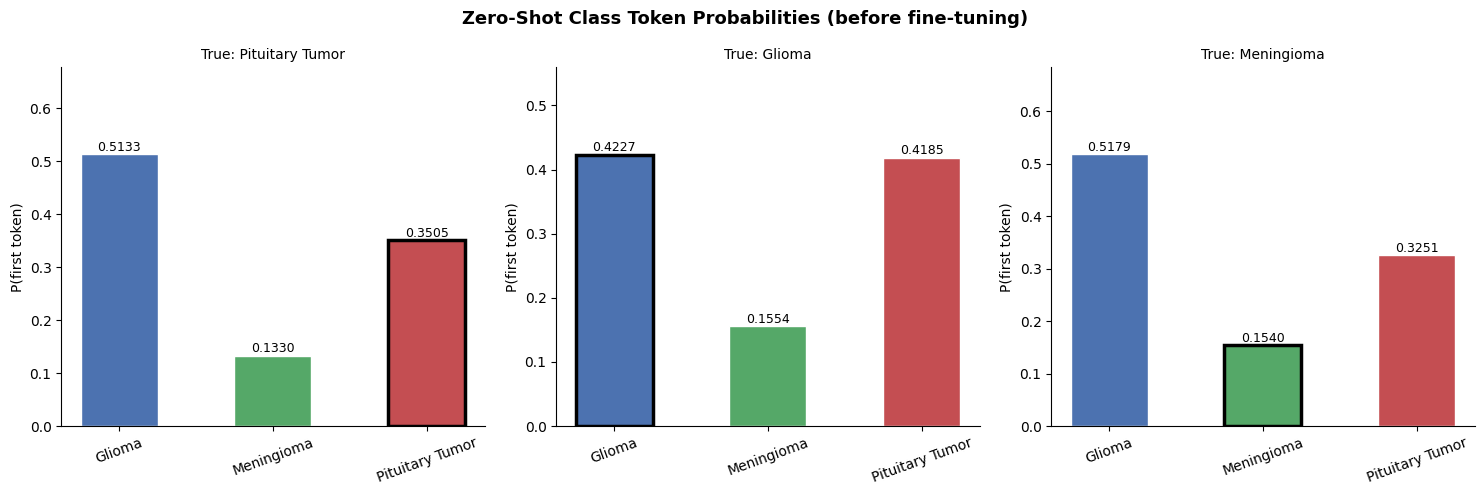

Saved figures/zero_shot_class_probs.png


In [17]:
# ── Visualise zero-shot class probabilities ────────────────────────────────────

CLASS_COLORS = {"Glioma": "#4C72B0", "Meningioma": "#55A868", "Pituitary Tumor": "#C44E52"}

fig, axes = plt.subplots(1, len(probe_samples), figsize=(5 * len(probe_samples), 5))
fig.suptitle("Zero-Shot Class Token Probabilities (before fine-tuning)",
             fontsize=13, fontweight="bold")

for ax, s in zip(axes, probe_samples):
    true_label = s["label"]
    cp = ZERO_SHOT_CLASS_PROBS[true_label]
    labels_plot = list(cp.keys())
    probs_plot  = list(cp.values())
    colors_plot = [CLASS_COLORS[l] for l in labels_plot]

    bars = ax.bar(labels_plot, probs_plot, color=colors_plot, edgecolor="white", width=0.5)
    for bar, p in zip(bars, probs_plot):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{p:.4f}", ha="center", va="bottom", fontsize=9)

    # Highlight the true label
    true_idx = labels_plot.index(true_label)
    bars[true_idx].set_edgecolor("black")
    bars[true_idx].set_linewidth(2.5)

    ax.set_title(f"True: {true_label}", fontsize=10)
    ax.set_ylim(0, max(probs_plot) * 1.3 + 0.01)
    ax.set_ylabel("P(first token)")
    ax.tick_params(axis="x", rotation=20)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/zero_shot_class_probs.png", dpi=200)
plt.show()
print("Saved figures/zero_shot_class_probs.png")

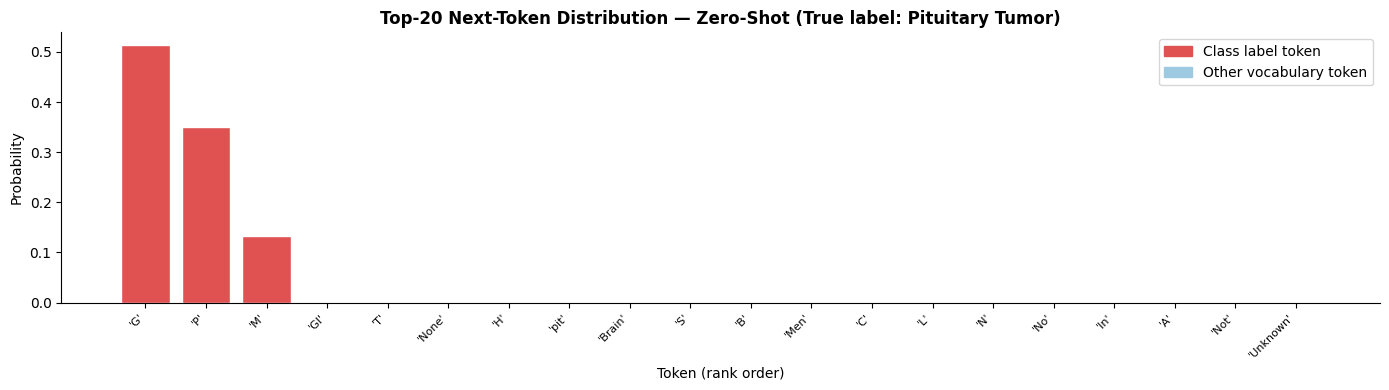

In [18]:
# ── Visualise the full top-20 vocabulary distribution for one sample ──────────

sample_label = probe_samples[0]["label"]
topk_df = ZERO_SHOT_TOPK[sample_label]

# Flag which rows are class-label tokens
all_class_first_ids = {tids[0] for tids in LABEL_TOKEN_IDS.values()}
topk_df["is_class_token"] = topk_df["token_id"].isin(all_class_first_ids)

bar_colors = [
    "#E05252" if is_ct else "#9ecae1"
    for is_ct in topk_df["is_class_token"]
]

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(
    range(len(topk_df)),
    topk_df["probability"],
    color=bar_colors, edgecolor="white"
)
ax.set_xticks(range(len(topk_df)))
ax.set_xticklabels(
    [repr(r) for r in topk_df["decoded"]], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Token (rank order)")
ax.set_ylabel("Probability")
ax.set_title(
    f"Top-20 Next-Token Distribution — Zero-Shot (True label: {sample_label})",
    fontsize=12, fontweight="bold")

legend_elements = [
    mpatches.Patch(color="#E05252", label="Class label token"),
    mpatches.Patch(color="#9ecae1", label="Other vocabulary token"),
]
ax.legend(handles=legend_elements)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/zero_shot_topk_distribution.png", dpi=200)
plt.show()

## Section 4 — Teacher Forcing: Theory & Visualisation

### 4.1 What is Teacher Forcing?

In standard **autoregressive generation**, the model generates token $t$ by conditioning
on the input + all previously *generated* tokens $\hat{y}_1, \ldots, \hat{y}_{t-1}$.  
If the model generates a wrong token early on, the error propagates — this is called
**exposure bias**.

In **teacher forcing**, during *training*, the model instead receives the *ground-truth*
previous tokens $y_1, \ldots, y_{t-1}$ as context.  The full sequence (prompt + correct
answer) is passed in **one forward pass**, and the loss is computed only on the answer
tokens.

```
Teacher-Forced Input Sequence
─────────────────────────────────────────────────────────────────────────────
  [system]  [user: image + prompt]  [assistant: <CLASS_LABEL>]  [eos]
  ├──────────────────────────────────┤ ├──────────────────────────────┤
  │     MASKED  (labels = -100)     │ │   SUPERVISED  (compute loss) │
  └──────────────────────────────────┘ └──────────────────────────────┘
```

The label mask (`-100`) tells `CrossEntropyLoss` to ignore those positions.
Only the assistant's answer tokens contribute to the gradient.

---

### 4.2 How the Loss is Computed — Step by Step

**Step 1 — One forward pass produces logits for every token position.**

Given the full token sequence $x_1 \ldots x_T$, the model computes

$$\mathbf{z}_t = f_\theta(x_1, \ldots, x_t) \in \mathbb{R}^{|V|}$$

where $|V|$ is the vocabulary size (~150 000 for Qwen2-VL).

**Step 2 — The logit at position $t-1$ predicts position $t$.**

Because the transformer is *causal*, $\mathbf{z}_{t-1}$ is the distribution over
what the model expects to see **at** position $t$.  
So to evaluate how well the model predicts answer token $y_t$, we look at
$\mathbf{z}_{t-1}$ and compute

$$p_\theta(y_t \mid x_{<t}) = \text{softmax}(\mathbf{z}_{t-1})[y_t]$$

**Step 3 — Cross-entropy loss over supervised positions only.**

Let $\mathcal{S}$ be the set of supervised (answer) token positions — positions where
`labels[t] != -100`.  The per-sample loss is:

$$\mathcal{L} = -\frac{1}{|\mathcal{S}|} \sum_{t \in \mathcal{S}}
\log p_\theta(y_t \mid x_{<t})$$

PyTorch's `CrossEntropyLoss` with `ignore_index=-100` implements this exactly:
it skips any position where the label is `-100` and averages only over $\mathcal{S}$.

**Step 4 — Why `-100`?**

`-100` is PyTorch's conventional sentinel for "do not compute loss here".
It is hardcoded as the default `ignore_index` in `nn.CrossEntropyLoss`.
Passing `labels` with `-100` at prompt positions means **zero gradient flows back
through those positions** — the model only learns from the answer tokens.

**Step 5 — Gradient flows only through supervised tokens.**

Because CE loss averages over $\mathcal{S}$, the gradient of $\mathcal{L}$
with respect to the LoRA adapter weights is determined entirely by how well
the model predicted each answer token.  For a 3-class label like
`"Pituitary Tumor"`, that is 2 tokens (`"Pituitary"` and `" Tumor"`);
for `"Glioma"` it is 1 token.  Shorter labels receive a stronger per-token
gradient signal for the same loss value.

---

### 4.3 How the Mask is Built

We find the boundary between prompt and answer by aligning the full-sequence
token ids with the prompt-only token ids using **Longest Common Prefix (LCP)**
matching, then fall back to searching for the `<|im_start|>assistant` sentinel
if tokenisation boundaries differ.


In [19]:
# ── Label mask computation (identical to training collator) ───────────────────

def compute_teacher_forcing_labels(full_inputs, prompt_inputs):
    """
    Returns a labels tensor identical to `full_inputs['input_ids']`
    except that all prompt tokens and padding tokens are set to -100.
    """
    labels  = full_inputs["input_ids"].clone()
    tok     = processor.tokenizer
    pad_id  = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id

    def _first_subseq(haystack, needle):
        if not needle: return -1
        n = len(needle)
        for j in range(len(haystack) - n + 1):
            if haystack[j: j + n] == needle:
                return j
        return -1

    for i in range(labels.shape[0]):
        flen = int(full_inputs["attention_mask"][i].sum().item())
        plen = int(prompt_inputs["attention_mask"][i].sum().item())
        fi   = full_inputs["input_ids"][i, :flen]
        pi   = prompt_inputs["input_ids"][i, :plen]

        # Longest common prefix
        k = 0
        while k < min(fi.shape[0], pi.shape[0]) and fi[k].item() == pi[k].item():
            k += 1
        prompt_len = k

        # Fallback: search for assistant header sentinel
        seq = fi.tolist()
        for sentinel in ("\n<|im_start|>assistant\n", "<|im_start|>assistant\n",
                          "<|im_start|>assistant"):
            nid = tok.encode(sentinel, add_special_tokens=False)
            pos = _first_subseq(seq, nid)
            if pos >= 0:
                prompt_len = pos
                break

        labels[i, :prompt_len]                          = -100
        labels[i, full_inputs["input_ids"][i] == pad_id] = -100

    return labels


print("compute_teacher_forcing_labels() defined.")

compute_teacher_forcing_labels() defined.


In [20]:
# ── Numerical demonstration: how cross-entropy loss is computed ───────────────
# Mirrors exactly what Trainer does internally.
# Run the cell above first (defines compute_teacher_forcing_labels), then this one.
if "compute_teacher_forcing_labels" not in globals():
    raise RuntimeError(
        "Run the previous cell first (compute_teacher_forcing_labels)."
    )

import torch.nn.functional as F

def compute_ce_loss_breakdown(image_path, true_label):
    """
    Manually replicates PyTorch CrossEntropyLoss(ignore_index=-100)
    so every arithmetic step is visible.

    Returns
    -------
    loss_manual   : float — mean CE over supervised positions (matches model output)
    token_rows    : list[dict] — per supervised-token breakdown
    """
    ensure_model()
    model.eval()
    tok   = processor.tokenizer
    image = Image.open(image_path).convert("RGB")

    # Build both sequences
    full_msgs   = build_vlm_messages(image, answer=true_label)
    prompt_msgs = build_vlm_messages(image, answer=None)
    full_text   = processor.apply_chat_template(full_msgs,   tokenize=False, add_generation_prompt=False)
    prompt_text = processor.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)

    full_inp   = processor(text=[full_text],   images=[image], return_tensors="pt",
                            padding=True, truncation=True, max_length=MAX_LENGTH)
    prompt_inp = processor(text=[prompt_text], images=[image], return_tensors="pt",
                            padding=True, truncation=True, max_length=MAX_LENGTH)

    labels = compute_teacher_forcing_labels(full_inp, prompt_inp)

    device = next(model.parameters()).device
    full_inp = {k: v.to(device) for k, v in full_inp.items()}
    labels   = labels.to(device)

    with torch.inference_mode():
        out = model(**full_inp, labels=labels, return_dict=True)

    # ── Manual replication of CrossEntropyLoss(ignore_index=-100) ──────────────
    # logits shape: (1, seq_len, vocab)
    logits   = out.logits[0].float()          # (seq_len, vocab)
    label_1d = labels[0]                      # (seq_len,)
    seq_len  = logits.shape[0]

    # The model predicts position t from logits at t-1
    # → supervised positions are those where label != -100
    sup_positions = (label_1d != -100).nonzero(as_tuple=True)[0].tolist()

    token_rows  = []
    manual_nll  = []

    for pos in sup_positions:
        if pos == 0:
            continue                          # can't use logit[-1] meaningfully
        target_id   = int(label_1d[pos].item())
        pred_logits = logits[pos - 1]         # distribution BEFORE seeing pos

        # Softmax → probability
        log_probs   = F.log_softmax(pred_logits, dim=-1)
        log_p_true  = float(log_probs[target_id].cpu())
        p_true      = float(log_probs[target_id].exp().cpu())

        # CE for this token = -log p(y_true)
        ce_token    = -log_p_true
        manual_nll.append(ce_token)

        piece, decoded = decode_token(target_id)
        token_rows.append({
            "position"     : pos,
            "token_id"     : target_id,
            "token_piece"  : piece,
            "decoded"      : decoded,
            "p(true_token)": round(p_true,  6),
            "-log p"       : round(ce_token, 6),   # per-token CE contribution
        })

    # Mean over supervised tokens  →  must match model's out.loss
    loss_manual = float(sum(manual_nll) / len(manual_nll)) if manual_nll else float("nan")
    loss_model  = float(out.loss.cpu()) if out.loss is not None else float("nan")

    print(f"\nLoss computation breakdown for label: \"{true_label}\"")
    print(f"  Supervised token positions : {[r['position'] for r in token_rows]}")
    print(f"  Per-token CE contributions :")
    for r in token_rows:
        print(f"    pos={r['position']:4d}  token={r['decoded']!r:18s}  "
              f"p={r['p(true_token)']:.6f}  -log p={r['-log p']:.6f}")
    print(f"\n  Manual mean CE  : {loss_manual:.6f}")
    print(f"  Model out.loss  : {loss_model:.6f}")
    print(f"  Match (< 1e-4)  : {abs(loss_manual - loss_model) < 1e-4}")

    return loss_manual, token_rows


# Run on one sample so the output is visible
s0 = probe_samples[0]
loss_demo, token_rows_demo = compute_ce_loss_breakdown(s0["image"], s0["label"])

# Display as DataFrame
import pandas as pd
display(pd.DataFrame(token_rows_demo))



Loss computation breakdown for label: "Pituitary Tumor"
  Supervised token positions : [390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401]
  Per-token CE contributions :
    pos= 390  token='\n'                p=1.000000  -log p=0.000000
    pos= 391  token='<|im_start|>'      p=0.000000  -log p=17.380913
    pos= 392  token='assistant'         p=0.000001  -log p=13.643377
    pos= 393  token='\n'                p=1.000000  -log p=0.000000
    pos= 394  token='P'                 p=0.350518  -log p=1.048344
    pos= 395  token='it'                p=0.999716  -log p=0.000284
    pos= 396  token='uit'               p=1.000000  -log p=0.000000
    pos= 397  token='ary'               p=1.000000  -log p=-0.000000
    pos= 398  token=' T'                p=0.999405  -log p=0.000596
    pos= 399  token='umor'              p=0.999998  -log p=0.000002
    pos= 400  token='<|im_end|>'        p=0.999994  -log p=0.000006
    pos= 401  token='\n'                p=1.000000  -log p=-0.000000


,position,token_id,token_piece,decoded,p(true_token),-log p
0,390,198,Ċ,\n,1.000000,0.000000
1,391,151644,<|im_start|>,<|im_start|>,0.000000,17.380913
2,392,77091,assistant,assistant,0.000001,13.643377
3,393,198,Ċ,\n,1.000000,0.000000
4,394,47,P,P,0.350518,1.048344
5,395,275,it,it,0.999716,0.000284
6,396,3083,uit,uit,1.000000,0.000000
7,397,658,ary,ary,1.000000,-0.000000
8,398,350,ĠT,T,0.999405,0.000596
9,399,68261,umor,umor,0.999998,0.000002



Sequence length  : 402
Masked positions : 390  (prompt + padding → ignored by loss)
Supervised       : 12  (answer tokens → contribute to loss)

Supervised tokens (the model must predict these):
  pos= 390  id=   198  piece='Ċ'                   decoded='\n'
  pos= 391  id=151644  piece='<|im_start|>'        decoded='<|im_start|>'
  pos= 392  id= 77091  piece='assistant'           decoded='assistant'
  pos= 393  id=   198  piece='Ċ'                   decoded='\n'
  pos= 394  id=    47  piece='P'                   decoded='P'
  pos= 395  id=   275  piece='it'                  decoded='it'
  pos= 396  id=  3083  piece='uit'                 decoded='uit'
  pos= 397  id=   658  piece='ary'                 decoded='ary'
  pos= 398  id=   350  piece='ĠT'                  decoded=' T'
  pos= 399  id= 68261  piece='umor'                decoded='umor'
  pos= 400  id=151645  piece='<|im_end|>'          decoded='<|im_end|>'
  pos= 401  id=   198  piece='Ċ'                   decoded='\n'


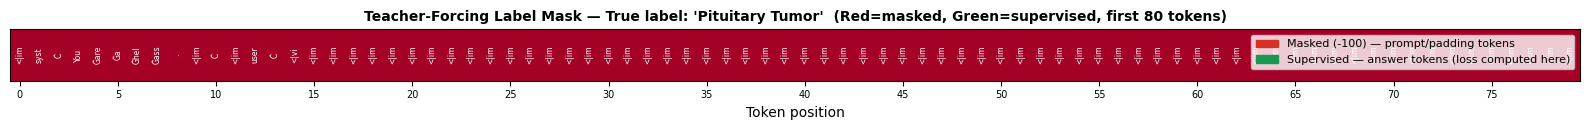

In [21]:
# ── Visualise the teacher-forcing mask for one sample ────────────────────────

def visualise_teacher_forcing_mask(image_path, true_label):
    """
    Renders a colour-coded token sequence showing which positions are
    masked (-100) and which are supervised (contribute to loss).
    """
    image = Image.open(image_path).convert("RGB")
    tok   = processor.tokenizer

    full_msgs   = build_vlm_messages(image, answer=true_label)
    prompt_msgs = build_vlm_messages(image, answer=None)

    full_text   = processor.apply_chat_template(full_msgs,   tokenize=False, add_generation_prompt=False)
    prompt_text = processor.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)

    full_inputs   = processor(text=[full_text],   images=[image], return_tensors="pt",
                               padding=True, truncation=True, max_length=MAX_LENGTH)
    prompt_inputs = processor(text=[prompt_text], images=[image], return_tensors="pt",
                               padding=True, truncation=True, max_length=MAX_LENGTH)

    labels = compute_teacher_forcing_labels(full_inputs, prompt_inputs)

    ids    = full_inputs["input_ids"][0].tolist()
    lbls   = labels[0].tolist()

    # Decode pieces
    pieces = tok.convert_ids_to_tokens(ids)

    # Build summary
    n_total      = len(ids)
    n_masked     = sum(1 for l in lbls if l == -100)
    n_supervised = sum(1 for l in lbls if l != -100)

    print(f"\nSequence length  : {n_total}")
    print(f"Masked positions : {n_masked}  (prompt + padding → ignored by loss)")
    print(f"Supervised       : {n_supervised}  (answer tokens → contribute to loss)")

    # Show the supervised tokens
    supervised = [(i, pieces[i], ids[i]) for i, l in enumerate(lbls) if l != -100]
    print("\nSupervised tokens (the model must predict these):")
    for pos, piece, tid in supervised:
        _, decoded = decode_token(tid)
        print(f"  pos={pos:4d}  id={tid:6d}  piece={piece!r:20s}  decoded={decoded!r}")

    # ── Pixel-level visualisation ─────────────────────────────────────────────
    show_n = min(n_total, 80)   # show first 80 tokens
    mask_arr = np.array([0 if l == -100 else 1 for l in lbls[:show_n]]).reshape(1, -1)

    fig, ax = plt.subplots(figsize=(16, 1.4))
    ax.imshow(mask_arr, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1,
              interpolation="nearest")

    # Annotate with token pieces (truncate for readability)
    for j in range(show_n):
        color = "white" if mask_arr[0, j] == 0 else "black"
        label_text = pieces[j][:4] if pieces[j] else ""
        ax.text(j, 0, label_text, ha="center", va="center",
                fontsize=5.5, color=color, rotation=90)

    ax.set_xticks(range(0, show_n, 5))
    ax.set_xticklabels(range(0, show_n, 5), fontsize=7)
    ax.set_yticks([])
    ax.set_xlabel("Token position")
    ax.set_title(
        f"Teacher-Forcing Label Mask — True label: '{true_label}'  "
        f"(Red=masked, Green=supervised, first {show_n} tokens)",
        fontsize=10, fontweight="bold")

    legend_elements = [
        mpatches.Patch(color="#d73027", label="Masked (-100) — prompt/padding tokens"),
        mpatches.Patch(color="#1a9850", label="Supervised — answer tokens (loss computed here)"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.savefig("figures/teacher_forcing_mask.png", dpi=200)
    plt.show()

    return labels, full_inputs, prompt_inputs


# Run on the first test sample
s0       = probe_samples[0]
tf_labels, tf_full_inputs, tf_prompt_inputs = visualise_teacher_forcing_mask(
    s0["image"], s0["label"])

In [22]:
# ── Per-label-token probability (teacher-forced forward pass) ─────────────────

def probe_teacher_forcing_probs(image_path, true_label, top_k=10):
    """
    Does a teacher-forced forward pass and, for every supervised position,
    returns:
      - The probability the model assigns to the TRUE label token
      - The top-k competing tokens at that position
      - The cross-entropy loss
    """
    ensure_model()
    model.eval()
    image = Image.open(image_path).convert("RGB")
    tok   = processor.tokenizer

    full_msgs   = build_vlm_messages(image, answer=true_label)
    prompt_msgs = build_vlm_messages(image, answer=None)

    full_text   = processor.apply_chat_template(full_msgs,   tokenize=False, add_generation_prompt=False)
    prompt_text = processor.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)

    full_inp   = processor(text=[full_text],   images=[image], return_tensors="pt",
                            padding=True, truncation=True, max_length=MAX_LENGTH)
    prompt_inp = processor(text=[prompt_text], images=[image], return_tensors="pt",
                            padding=True, truncation=True, max_length=MAX_LENGTH)

    labels = compute_teacher_forcing_labels(full_inp, prompt_inp)

    device = next(model.parameters()).device
    full_inp = {k: v.to(device) for k, v in full_inp.items()}
    labels   = labels.to(device)

    with torch.inference_mode():
        out = model(**full_inp, labels=labels, return_dict=True)

    logits   = out.logits[0].float()     # (seq_len, vocab)
    label_ids = labels[0].cpu().tolist()

    supervised_pos = [i for i, l in enumerate(label_ids) if l != -100]

    rows, topk_rows = [], []
    for step, pos in enumerate(supervised_pos):
        if pos == 0:
            continue
        target_id   = label_ids[pos]
        pred_probs  = torch.softmax(logits[pos - 1], dim=-1)
        target_prob = float(pred_probs[target_id].cpu())

        piece, decoded = decode_token(target_id)
        rows.append({
            "step": step,
            "position": pos,
            "target_token_id": target_id,
            "target_piece": piece,
            "target_decoded": decoded,
            "target_prob": target_prob,
            "neg_log_prob": float(-torch.log(pred_probs[target_id] + 1e-12).cpu()),
        })

        tp, ti = torch.topk(pred_probs, k=top_k)
        for rank, (cid, cp) in enumerate(zip(ti.tolist(), tp.tolist()), 1):
            cp2, cd = decode_token(cid)
            topk_rows.append({
                "step": step, "rank": rank,
                "token_id": cid, "piece": cp2, "decoded": cd,
                "prob": cp,
                "is_target": cid == target_id,
            })

    loss = float(out.loss.cpu()) if out.loss is not None else None
    return pd.DataFrame(rows), pd.DataFrame(topk_rows), loss


print("probe_teacher_forcing_probs() defined.")

probe_teacher_forcing_probs() defined.


In [23]:
# ── Run teacher-forcing probe — zero-shot ─────────────────────────────────────

ZERO_SHOT_TF = {}   # {true_label: (label_prob_df, topk_df, loss)}

for s in probe_samples:
    true_label = s["label"]
    print(f"\n{'='*60}")
    print(f"Teacher-forcing probe — True label: {true_label}")
    print(f"{'='*60}")
    lp_df, topk_df, loss = probe_teacher_forcing_probs(s["image"], true_label, top_k=10)
    ZERO_SHOT_TF[true_label] = (lp_df, topk_df, loss)
    print(f"  Cross-entropy loss   : {loss:.4f}")
    print(f"  Per-token probabilities:")
    display(lp_df[["step","target_piece","target_decoded","target_prob","neg_log_prob"]])
    print(f"  Top-10 at step 0 (first answer token):")
    display(topk_df[topk_df["step"]==lp_df.iloc[0]["step"]]
            [["rank","piece","decoded","prob","is_target"]])


Teacher-forcing probe — True label: Pituitary Tumor
  Cross-entropy loss   : 2.6728
  Per-token probabilities:


,step,target_piece,target_decoded,target_prob,neg_log_prob
0,0,Ċ,\n,9.999998e-01,2.384186e-07
1,1,<|im_start|>,<|im_start|>,2.828560e-08,1.738088e+01
2,2,assistant,assistant,1.187836e-06,1.364338e+01
3,3,Ċ,\n,9.999995e-01,4.768373e-07
4,4,P,P,3.505179e-01,1.048344e+00
5,5,it,it,9.997162e-01,2.838180e-04
6,6,uit,uit,9.999998e-01,2.384186e-07
7,7,ary,ary,1.000000e+00,-0.000000e+00
8,8,ĠT,T,9.994045e-01,5.956278e-04
9,9,umor,umor,9.999985e-01,1.549722e-06


  Top-10 at step 0 (first answer token):


,rank,piece,decoded,prob,is_target
0,1,Ċ,\n,9.999998e-01,True
1,2,čĊ,\r\n,2.141211e-07,False
2,3,ĊĊ,\n\n,2.327078e-08,False
3,4,\n,\n,3.215315e-10,False
4,5,`Ċ,`\n,5.802137e-11,False
5,6,ĠĊ,\n,1.536123e-11,False
6,7,x,x,8.727246e-12,False
7,8,ĊĊĊ,\n\n\n,7.212462e-12,False
8,9,p,p,6.794259e-12,False
9,10,ĊĠĠĠĊ,\n \n,2.705060e-12,False



Teacher-forcing probe — True label: Glioma
  Cross-entropy loss   : 3.9002
  Per-token probabilities:


...

,rank,piece,decoded,prob,is_target
0,1,Ċ,\n,9.999998e-01,True
1,2,čĊ,\r\n,1.728972e-07,False
2,3,ĊĊ,\n\n,1.513690e-08,False
3,4,\n,\n,2.434795e-10,False
4,5,`Ċ,`\n,5.648521e-11,False
5,6,ĠĊ,\n,1.622130e-11,False
6,7,ĊĊĊ,\n\n\n,5.219285e-12,False
7,8,x,x,4.801320e-12,False
8,9,p,p,4.074750e-12,False
9,10,ĊĠĠĠĊ,\n \n,2.097609e-12,False



Teacher-forcing probe — True label: Meningioma
  Cross-entropy loss   : 3.3841
  Per-token probabilities:


,step,target_piece,target_decoded,target_prob,neg_log_prob
0,0,Ċ,\n,9.999998e-01,2.384186e-07
1,1,<|im_start|>,<|im_start|>,2.671310e-08,1.743807e+01
2,2,assistant,assistant,4.885813e-07,1.453176e+01
3,3,Ċ,\n,9.999998e-01,2.384186e-07
4,4,M,M,1.540246e-01,1.870643e+00
5,5,ening,ening,9.997954e-01,2.046437e-04
6,6,i,i,9.999970e-01,2.980237e-06
7,7,oma,oma,9.999994e-01,5.960466e-07
8,8,<|im_end|>,<|im_end|>,9.999973e-01,2.741818e-06
9,9,Ċ,\n,1.000000e+00,-0.000000e+00


  Top-10 at step 0 (first answer token):


,rank,piece,decoded,prob,is_target
0,1,Ċ,\n,9.999998e-01,True
1,2,čĊ,\r\n,1.692281e-07,False
2,3,ĊĊ,\n\n,1.955396e-08,False
3,4,\n,\n,2.057119e-10,False
4,5,`Ċ,`\n,5.322756e-11,False
5,6,ĠĊ,\n,1.244793e-11,False
6,7,x,x,6.389558e-12,False
7,8,p,p,4.650733e-12,False
8,9,ĊĊĊ,\n\n\n,4.648489e-12,False
9,10,ĊĠĠĠĊ,\n \n,1.995169e-12,False


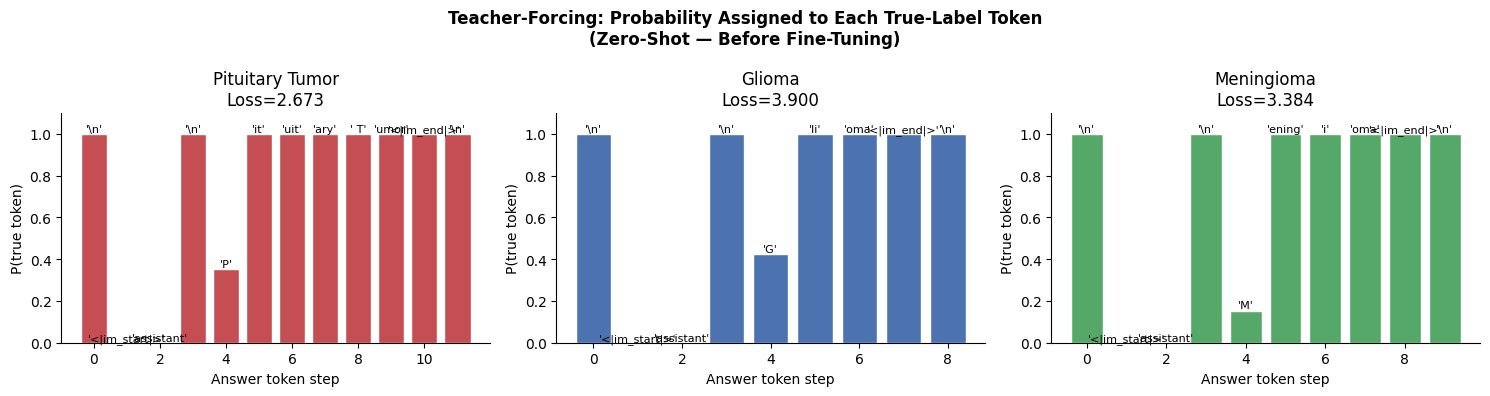

In [24]:
# ── Visualise per-token probabilities (teacher-forced, zero-shot) ─────────────

fig, axes = plt.subplots(1, len(probe_samples), figsize=(5 * len(probe_samples), 4))
fig.suptitle("Teacher-Forcing: Probability Assigned to Each True-Label Token\n"
             "(Zero-Shot — Before Fine-Tuning)",
             fontsize=12, fontweight="bold")

for ax, s in zip(axes, probe_samples):
    true_label = s["label"]
    lp_df, _, loss = ZERO_SHOT_TF[true_label]

    ax.bar(lp_df["step"], lp_df["target_prob"],
           color=CLASS_COLORS[true_label], edgecolor="white")

    for _, row in lp_df.iterrows():
        ax.text(row["step"], row["target_prob"] + 0.01,
                repr(row["target_decoded"]), ha="center", fontsize=8)

    ax.set_ylim(0, 1.1)
    ax.set_xlabel("Answer token step")
    ax.set_ylabel("P(true token)")
    ax.set_title(f"{true_label}\nLoss={loss:.3f}")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/zero_shot_tf_token_probs.png", dpi=200)
plt.show()

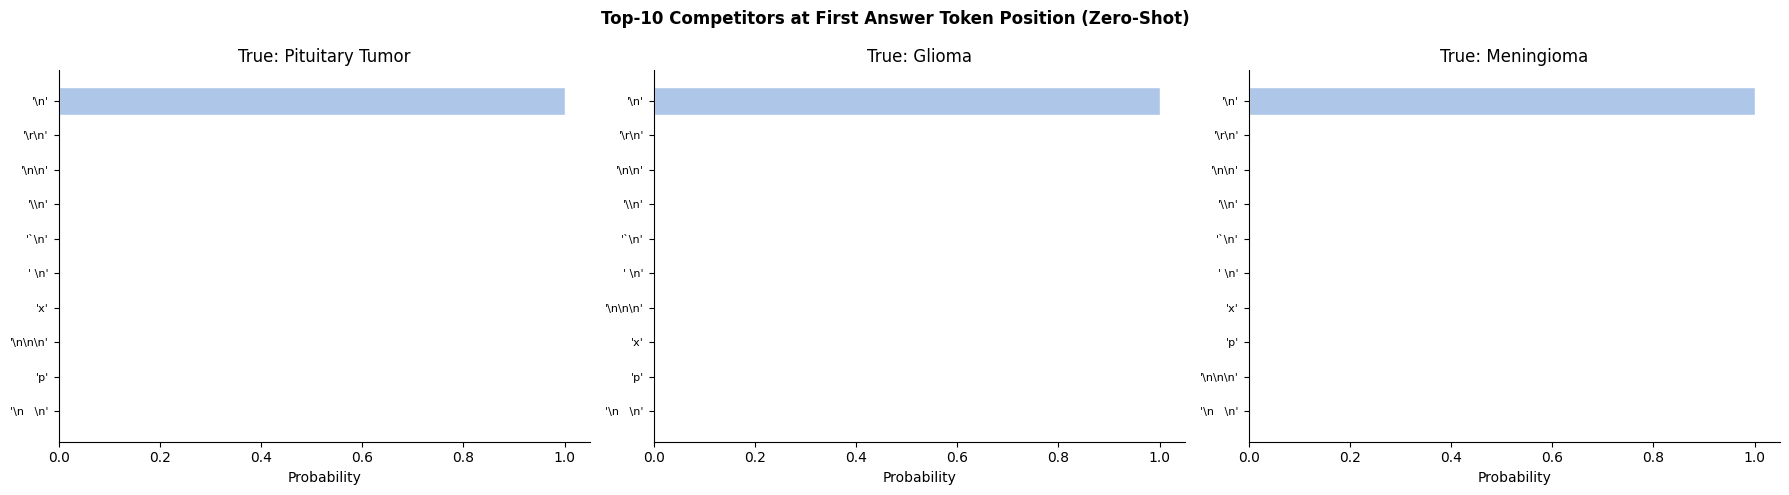

In [25]:
# ── Top-k competitor chart for the first answer token ─────────────────────────
# Shows how the probability mass is spread across the vocabulary
# at the most critical position: "what class will the model say?"

fig, axes = plt.subplots(1, len(probe_samples), figsize=(6 * len(probe_samples), 5))
fig.suptitle("Top-10 Competitors at First Answer Token Position (Zero-Shot)",
             fontsize=12, fontweight="bold")

for ax, s in zip(axes, probe_samples):
    true_label = s["label"]
    _, topk_df, _ = ZERO_SHOT_TF[true_label]
    step0 = topk_df["step"].min()
    df0   = topk_df[topk_df["step"] == step0].copy()

    colors = [CLASS_COLORS.get(df0.iloc[i]["decoded"].strip(), "#aec7e8")
              if df0.iloc[i]["is_target"] else
              ("#fdae6b" if any(df0.iloc[i]["decoded"].strip().startswith(l[:4])
                               for l in LABELS)
               else "#c6dbef")
              for i in range(len(df0))]

    bars = ax.barh(range(len(df0)), df0["prob"].values[::-1],
                   color=colors[::-1], edgecolor="white")
    ax.set_yticks(range(len(df0)))
    ax.set_yticklabels([repr(d) for d in df0["decoded"].values[::-1]], fontsize=8)
    ax.set_xlabel("Probability")
    ax.set_title(f"True: {true_label}")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/zero_shot_topk_competitors.png", dpi=200)
plt.show()

## Section 5 — Dataset & Teacher-Forcing Collator

In [26]:
class MRIVLMDataset(Dataset):
    def __init__(self, jsonl_path):
        with open(jsonl_path, encoding="utf-8") as f:
            self.samples = [json.loads(l) for l in f]

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        item  = self.samples[idx]
        image = Image.open(item["image"]).convert("RGB")
        label = item["label"]
        return {
            "image": image,
            "label": label,
            "messages_full":        build_vlm_messages(image, answer=label),
            "messages_prompt_only": build_vlm_messages(image, answer=None),
        }


def vlm_teacher_forcing_collator(batch):
    """
    Collates a batch into teacher-forced model inputs.

    Key steps:
      1. Render the FULL sequence (prompt + answer) for each sample.
      2. Render the PROMPT-ONLY sequence.
      3. Build the label mask: -100 everywhere except the answer tokens.
      4. Attach labels to full_inputs — the Trainer uses these for loss.
    """
    images, full_texts, prompt_texts = [], [], []

    for item in batch:
        images.append(item["image"])
        full_texts.append(processor.apply_chat_template(
            item["messages_full"], tokenize=False, add_generation_prompt=False))
        prompt_texts.append(processor.apply_chat_template(
            item["messages_prompt_only"], tokenize=False, add_generation_prompt=False))

    full_inputs   = processor(text=full_texts,   images=images, return_tensors="pt",
                               padding=True, truncation=True, max_length=MAX_LENGTH)
    prompt_inputs = processor(text=prompt_texts, images=images, return_tensors="pt",
                               padding=True, truncation=True, max_length=MAX_LENGTH)

    full_inputs["labels"] = compute_teacher_forcing_labels(full_inputs, prompt_inputs)
    return full_inputs


train_dataset = MRIVLMDataset("train.jsonl")
val_dataset   = MRIVLMDataset("val.jsonl")
test_dataset  = MRIVLMDataset("test.jsonl")

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")

# Sanity-check collator on two samples
test_batch = vlm_teacher_forcing_collator([train_dataset[i] for i in range(2)])
n_sup = (test_batch["labels"] != -100).sum().item()
print(f"Batch input_ids shape : {test_batch['input_ids'].shape}")
print(f"Supervised tokens     : {n_sup}")
assert n_sup > 0, "Mask error: no supervised tokens found! Check MAX_LENGTH."

Train: 1050  Val: 150  Test: 300
Batch input_ids shape : torch.Size([2, 402])
Supervised tokens     : 24


## Section 6 — LoRA Fine-Tuning with Teacher Forcing

In [27]:
# ── QA Monitor Callback — live inference probe during training ────────────────
#
# At every eval checkpoint the callback:
#   1. Runs greedy generation on `probe_samples` (one per class).
#   2. Records predicted label, raw output, and class-token probabilities.
#   3. Appends a row to results/qa_monitor/qa_log.csv.
#   4. Saves a bar-chart figure to results/qa_monitor/step_<N>.png.
#
# After training you can load qa_log.csv to see how the model's answers
# evolved across checkpoints — a direct window into learning dynamics.

import csv, pathlib, re
from transformers import TrainerCallback, TrainerControl, TrainerState


def clean_prediction(text):
    """Map model text to one of LABELS (used by QAMonitorCallback and Section 9)."""
    text = (text or "").strip()
    if not text:
        return "Unknown"
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r"<[^>]{1,120}>", "", text)
    text = text.replace("**", "").replace("*", "").strip()
    low = text.lower()
    if "meningioma" in low:
        return "Meningioma"
    if "glioma" in low:
        return "Glioma"
    if "pituitary" in low:
        return "Pituitary Tumor"
    for label in sorted(LABELS, key=len, reverse=True):
        if label.lower() in low:
            return label
    m = re.search(r"\b[012]\b", text)
    if m:
        idx = int(m.group())
        if 0 <= idx < len(LABELS):
            return LABELS[idx]
    return "Unknown"


QA_MONITOR_DIR = pathlib.Path("results/qa_monitor")
QA_MONITOR_DIR.mkdir(parents=True, exist_ok=True)
QA_LOG_CSV     = QA_MONITOR_DIR / "qa_log.csv"

_QA_CSV_HEADER = [
    "global_step", "epoch",
    "true_label", "raw_output", "predicted_label", "correct",
    "p_glioma", "p_meningioma", "p_pituitary",
]

# Initialise log file with header (overwrite on each full run)
with open(QA_LOG_CSV, "w", newline="", encoding="utf-8") as fh:
    csv.DictWriter(fh, fieldnames=_QA_CSV_HEADER).writeheader()


class QAMonitorCallback(TrainerCallback):
    """
    Runs a greedy-generation QA probe at every evaluation step.

    Implementation notes
    --------------------
    * We call `model.eval()` explicitly and restore training mode afterwards
      so Trainer's own gradient flow is unaffected.
    * Probabilities are taken from a single forward pass (no generation
      overhead) at the first answer-token position — the same position
      probed in Section 3.
    * All disk I/O uses `pathlib` and `csv` — no extra dependencies.
    """

    def on_evaluate(self, args, state: TrainerState, control: TrainerControl, **kwargs):
        step  = state.global_step
        epoch = round(state.epoch or 0, 3)
        print(f"\n[QAMonitor] step={step}  epoch={epoch} — running QA probe …")

        model.eval()
        tok    = processor.tokenizer
        pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id
        eos_id = tok.eos_token_id
        device = next(model.parameters()).device

        log_rows = []
        fig, axes = plt.subplots(1, len(probe_samples),
                                 figsize=(5 * len(probe_samples), 4))
        if len(probe_samples) == 1:
            axes = [axes]

        for ax, s in zip(axes, probe_samples):
            true_label  = s["label"]
            image_path  = s["image"]
            image       = Image.open(image_path).convert("RGB")

            # ── 1. Greedy generation ───────────────────────────────────────────
            msgs     = build_vlm_messages(image, answer=None)
            text     = processor.apply_chat_template(
                            msgs, tokenize=False, add_generation_prompt=True)
            inputs   = processor(text=[text], images=[image], return_tensors="pt",
                                  truncation=True, max_length=MAX_LENGTH)
            inputs   = {k: v.to(device) for k, v in inputs.items()}

            with torch.inference_mode():
                gen_ids = model.generate(
                    **inputs, max_new_tokens=8,
                    do_sample=False, num_beams=1,
                    pad_token_id=pad_id, eos_token_id=eos_id)

            in_len      = inputs["input_ids"].shape[1]
            raw_output  = tok.decode(gen_ids[0][in_len:], skip_special_tokens=True)
            pred_label  = clean_prediction(raw_output)
            correct     = int(pred_label == true_label)

            # ── 2. Class-token probabilities (forward pass, no generation) ─────
            with torch.inference_mode():
                fwd_out = model(**inputs, return_dict=True)
            last_logits = fwd_out.logits[0, -1, :].float()
            probs_all   = torch.softmax(last_logits, dim=-1).cpu()
            class_probs = {lbl: float(probs_all[LABEL_TOKEN_IDS[lbl][0]])
                           for lbl in LABELS}

            # ── 3. Append to CSV ───────────────────────────────────────────────
            row = {
                "global_step"   : step,
                "epoch"         : epoch,
                "true_label"    : true_label,
                "raw_output"    : raw_output.strip(),
                "predicted_label": pred_label,
                "correct"       : correct,
                "p_glioma"      : round(class_probs["Glioma"],         6),
                "p_meningioma"  : round(class_probs["Meningioma"],     6),
                "p_pituitary"   : round(class_probs["Pituitary Tumor"],6),
            }
            log_rows.append(row)

            # ── 4. Bar chart for this sample ───────────────────────────────────
            colors_bar = [
                ("green" if lbl == true_label else "steelblue")
                for lbl in LABELS
            ]
            bars = ax.bar(LABELS,
                          [class_probs[l] for l in LABELS],
                          color=colors_bar, edgecolor="white")
            for bar, lbl in zip(bars, LABELS):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.002,
                        f"{class_probs[lbl]:.3f}",
                        ha="center", va="bottom", fontsize=8)

            tick_color = "green" if correct else "red"
            ax.set_title(
                f"True: {true_label}\nPred: {pred_label}",
                color=tick_color, fontsize=9, fontweight="bold")
            ax.set_ylim(0, 1.0)
            ax.set_ylabel("P(first token)")
            ax.tick_params(axis="x", rotation=20)
            ax.spines[["top", "right"]].set_visible(False)

        # ── 5. Save figure ─────────────────────────────────────────────────────
        fig.suptitle(f"QA Monitor — step {step}  epoch {epoch}",
                     fontsize=11, fontweight="bold")
        plt.tight_layout()
        fig_path = QA_MONITOR_DIR / f"step_{step:05d}.png"
        plt.savefig(fig_path, dpi=150)
        plt.close(fig)

        # ── 6. Append rows to CSV ──────────────────────────────────────────────
        with open(QA_LOG_CSV, "a", newline="", encoding="utf-8") as fh:
            writer = csv.DictWriter(fh, fieldnames=_QA_CSV_HEADER)
            writer.writerows(log_rows)

        n_correct = sum(r["correct"] for r in log_rows)
        print(f"[QAMonitor] step={step}  probe accuracy={n_correct}/{len(log_rows)}"
              f"  figure → {fig_path}")
        print(f"[QAMonitor] Predictions: "
              + "  |  ".join(f"{r['true_label']}→{r['predicted_label']}" for r in log_rows))

        model.train()   # restore training mode


# ── TrainingArguments ─────────────────────────────────────────────────────────

_use_grad_ckpt = os.environ.get("VLM_GRAD_CKPT", "0") == "1"
_ckpt_kwargs   = ({"gradient_checkpointing_kwargs": {"use_reentrant": True}}
                 if _use_grad_ckpt else {})

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.05,
    max_grad_norm=1.0,
    logging_steps=10,
    eval_strategy="steps",  eval_steps=100,
    save_strategy="steps",  save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=torch.cuda.is_available(), bf16=False,
    gradient_checkpointing=_use_grad_ckpt,
    torch_empty_cache_steps=4,
    remove_unused_columns=False,
    report_to="none",
    dataloader_num_workers=0,
    **_ckpt_kwargs,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=vlm_teacher_forcing_collator,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3),
        QAMonitorCallback(),        # ← live QA probe at every eval step
    ],
)

print(f"Gradient checkpointing : {'ON' if _use_grad_ckpt else 'OFF'}")
print(f"QA monitor log         : {QA_LOG_CSV}")
print(f"QA monitor figures     : {QA_MONITOR_DIR}/step_*.png")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Gradient checkpointing : OFF
QA monitor log         : results\qa_monitor\qa_log.csv
QA monitor figures     : results\qa_monitor/step_*.png


In [28]:
trainer.train()

c:\Users\legionPC9\anaconda3\envs\dl\lib\site-packages\torch\_dynamo\eval_frame.py:1298: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
100,0.021011,0.033419
200,0.003039,0.021262
300,0.000082,0.025906
330,0.000045,0.026373



[QAMonitor] step=100  epoch=1.518 — running QA probe …


c:\Users\legionPC9\anaconda3\envs\dl\lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[QAMonitor] step=100  probe accuracy=3/3  figure → results\qa_monitor\step_00100.png
[QAMonitor] Predictions: Pituitary Tumor→Pituitary Tumor  |  Glioma→Glioma  |  Meningioma→Meningioma


...

c:\Users\legionPC9\anaconda3\envs\dl\lib\site-packages\torch\_dynamo\eval_frame.py:1298: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)



[QAMonitor] step=330  epoch=5.0 — running QA probe …


c:\Users\legionPC9\anaconda3\envs\dl\lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[QAMonitor] step=330  probe accuracy=3/3  figure → results\qa_monitor\step_00330.png
[QAMonitor] Predictions: Pituitary Tumor→Pituitary Tumor  |  Glioma→Glioma  |  Meningioma→Meningioma


TrainOutput(global_step=330, training_loss=0.09319753556734543, metrics={'train_runtime': 6469.808, 'train_samples_per_second': 0.811, 'train_steps_per_second': 0.051, 'total_flos': 9.788244046381056e+16, 'train_loss': 0.09319753556734543, 'epoch': 5.0})

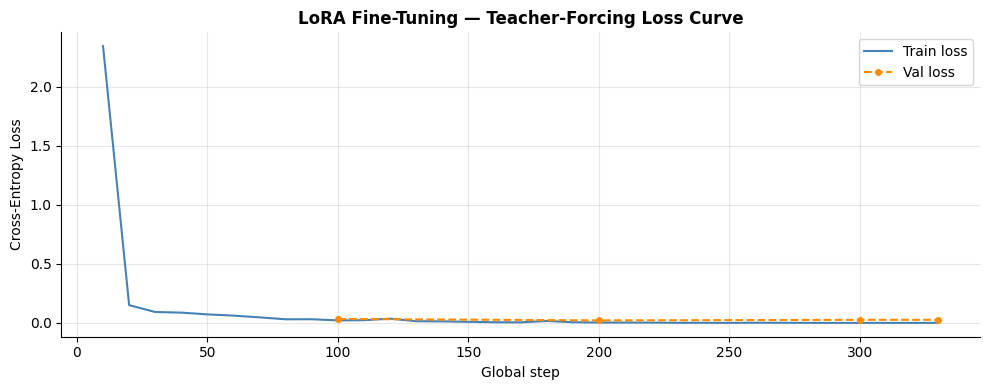

In [29]:
# ── Training loss curve ────────────────────────────────────────────────────────
log_history = trainer.state.log_history
train_logs  = [(e["step"], e["loss"]) for e in log_history if "loss" in e]
eval_logs   = [(e["step"], e["eval_loss"]) for e in log_history if "eval_loss" in e]

if train_logs:
    steps_tr, losses_tr = zip(*train_logs)
    steps_ev, losses_ev = zip(*eval_logs) if eval_logs else ([], [])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(steps_tr, losses_tr, label="Train loss", color="steelblue", linewidth=1.5)
    if steps_ev:
        ax.plot(steps_ev, losses_ev, label="Val loss", color="darkorange",
                linewidth=1.5, linestyle="--", marker="o", markersize=4)
    ax.set_xlabel("Global step"); ax.set_ylabel("Cross-Entropy Loss")
    ax.set_title("LoRA Fine-Tuning — Teacher-Forcing Loss Curve",
                 fontsize=12, fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("figures/training_loss_curve.png", dpi=200)
    plt.show()
else:
    print("No log history yet.")

In [30]:
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Model adapter saved to:", OUTPUT_DIR)

Model adapter saved to: ./qwen25vl_7b_mri_lora


QA log: 12 rows  ·  steps: [np.int64(100), np.int64(200), np.int64(300), np.int64(330)]


,global_step,epoch,true_label,raw_output,predicted_label,correct,p_glioma,p_meningioma,p_pituitary
0,100,1.518,Pituitary Tumor,Pituitary Tumor,Pituitary Tumor,1,0.105152,0.196450,0.696477
1,100,1.518,Glioma,Glioma,Glioma,1,0.999782,0.000098,0.000065
2,100,1.518,Meningioma,Meningioma,Meningioma,1,0.402593,0.594995,0.000923
3,200,3.030,Pituitary Tumor,Pituitary Tumor,Pituitary Tumor,1,0.001836,0.016365,0.981317
4,200,3.030,Glioma,Glioma,Glioma,1,0.999612,0.000320,0.000015
5,200,3.030,Meningioma,Meningioma,Meningioma,1,0.012231,0.986938,0.000126
6,300,4.549,Pituitary Tumor,Pituitary Tumor,Pituitary Tumor,1,0.000018,0.000544,0.999354
7,300,4.549,Glioma,Glioma,Glioma,1,0.999989,0.000001,0.000000
8,300,4.549,Meningioma,Meningioma,Meningioma,1,0.000047,0.999826,0.000001
9,330,5.000,Pituitary Tumor,Pituitary Tumor,Pituitary Tumor,1,0.000015,0.000451,0.999459


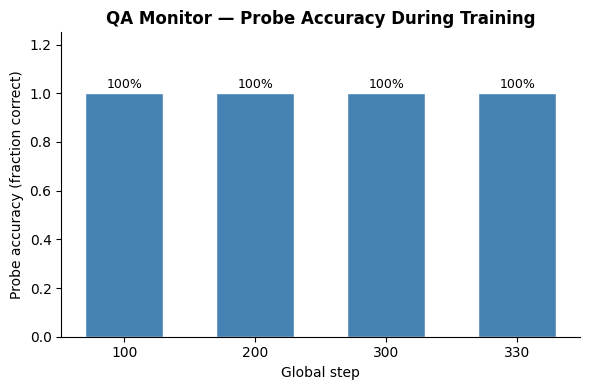

Saved figures/qa_monitor_accuracy.png


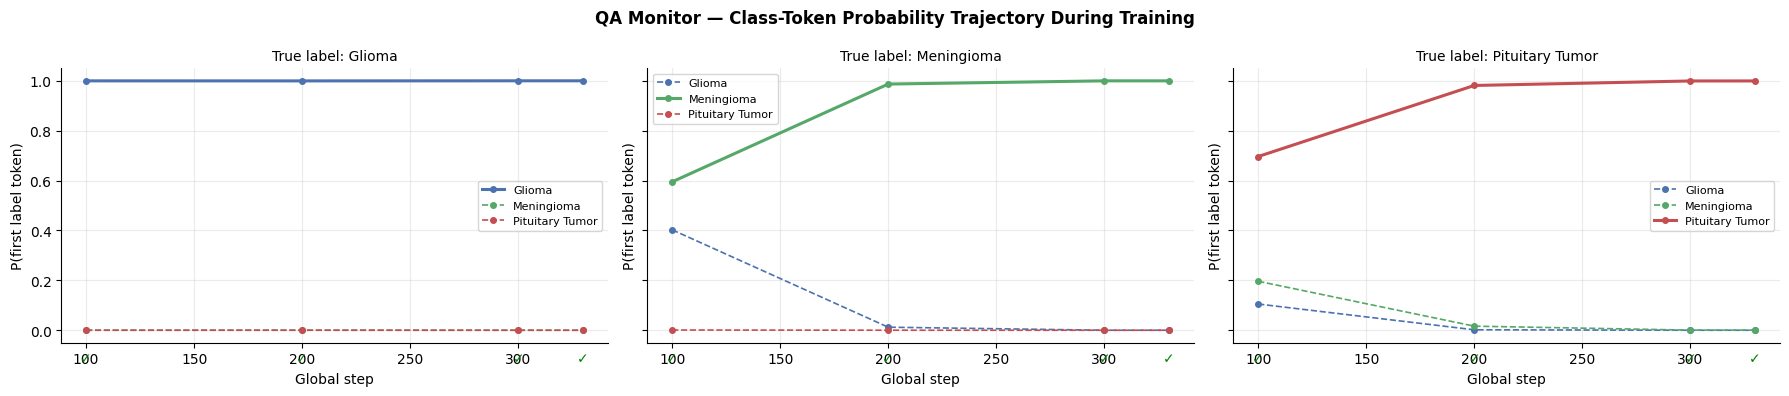

Saved figures/qa_monitor_probability_trajectory.png
Saved results/qa_monitor_summary.csv


,global_step,epoch,true_label,predicted_label,correct,p_glioma,p_meningioma,p_pituitary
0,100,1.518,Glioma,Glioma,1,0.999782,0.000098,0.000065
1,100,1.518,Meningioma,Meningioma,1,0.402593,0.594995,0.000923
2,100,1.518,Pituitary Tumor,Pituitary Tumor,1,0.105152,0.196450,0.696477
3,200,3.030,Glioma,Glioma,1,0.999612,0.000320,0.000015
4,200,3.030,Meningioma,Meningioma,1,0.012231,0.986938,0.000126
5,200,3.030,Pituitary Tumor,Pituitary Tumor,1,0.001836,0.016365,0.981317
6,300,4.549,Glioma,Glioma,1,0.999989,0.000001,0.000000
7,300,4.549,Meningioma,Meningioma,1,0.000047,0.999826,0.000001
8,300,4.549,Pituitary Tumor,Pituitary Tumor,1,0.000018,0.000544,0.999354
9,330,5.000,Glioma,Glioma,1,0.999990,0.000001,0.000000


In [31]:
# ── QA Monitor — post-training visualisation ─────────────────────────────────
# Loads the CSV written by QAMonitorCallback and plots:
#   (a) Accuracy-over-steps bar chart
#   (b) Class-token probability trajectories for each probe sample

import pathlib, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as mpatches

QA_LOG_CSV = pathlib.Path("results/qa_monitor/qa_log.csv")

if not QA_LOG_CSV.exists():
    print("No QA log found — run training first.")
else:
    qa_df = pd.read_csv(QA_LOG_CSV)
    print(f"QA log: {len(qa_df)} rows  ·  steps: {sorted(qa_df['global_step'].unique())}")
    display(qa_df.head(10))

    steps  = sorted(qa_df["global_step"].unique())
    labels_order = LABELS   # ["Glioma", "Meningioma", "Pituitary Tumor"]

    # ── (a) Per-step probe accuracy ───────────────────────────────────────────
    step_acc = qa_df.groupby("global_step")["correct"].mean()

    fig, ax = plt.subplots(figsize=(max(6, len(steps) * 0.8 + 2), 4))
    ax.bar(step_acc.index.astype(str), step_acc.values,
           color="steelblue", edgecolor="white", width=0.6)
    for x, y in zip(step_acc.index, step_acc.values):
        ax.text(str(x), y + 0.02, f"{y:.0%}", ha="center", fontsize=9)
    ax.set_ylim(0, 1.25)
    ax.set_xlabel("Global step")
    ax.set_ylabel("Probe accuracy (fraction correct)")
    ax.set_title("QA Monitor — Probe Accuracy During Training",
                 fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("figures/qa_monitor_accuracy.png", dpi=200)
    plt.show()
    print("Saved figures/qa_monitor_accuracy.png")

    # ── (b) Class-token probability trajectories ──────────────────────────────
    prob_cols = {"Glioma": "p_glioma",
                 "Meningioma": "p_meningioma",
                 "Pituitary Tumor": "p_pituitary"}

    n_probes = qa_df["true_label"].nunique()
    fig, axes = plt.subplots(1, n_probes, figsize=(6 * n_probes, 4), sharey=True)
    if n_probes == 1:
        axes = [axes]
    fig.suptitle("QA Monitor — Class-Token Probability Trajectory During Training",
                 fontsize=12, fontweight="bold")

    for ax, true_lbl in zip(axes, labels_order):
        sub = qa_df[qa_df["true_label"] == true_lbl].sort_values("global_step")
        if sub.empty:
            ax.set_title(f"{true_lbl}\n(no data)")
            continue

        for lbl, col in prob_cols.items():
            linestyle = "-" if lbl == true_lbl else "--"
            linewidth = 2.2 if lbl == true_lbl else 1.2
            ax.plot(sub["global_step"], sub[col],
                    label=lbl, color=CLASS_COLORS[lbl],
                    linestyle=linestyle, linewidth=linewidth, marker="o", markersize=4)

        # Mark correct/incorrect predictions
        for _, row in sub.iterrows():
            marker = "✓" if row["correct"] else "✗"
            color  = "green" if row["correct"] else "red"
            ax.text(row["global_step"], -0.07, marker,
                    ha="center", fontsize=10, color=color, transform=ax.get_xaxis_transform())

        ax.set_title(f"True label: {true_lbl}", fontsize=10)
        ax.set_xlabel("Global step")
        ax.set_ylabel("P(first label token)")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("figures/qa_monitor_probability_trajectory.png", dpi=200)
    plt.show()
    print("Saved figures/qa_monitor_probability_trajectory.png")

    # ── Save full summary table ───────────────────────────────────────────────
    summary = (qa_df.groupby(["global_step", "epoch", "true_label"])
                    .agg(predicted_label=("predicted_label", "first"),
                         correct=("correct", "first"),
                         p_glioma=("p_glioma", "first"),
                         p_meningioma=("p_meningioma", "first"),
                         p_pituitary=("p_pituitary", "first"))
                    .reset_index())
    summary.to_csv("results/qa_monitor_summary.csv", index=False)
    print("Saved results/qa_monitor_summary.csv")
    display(summary)


## Section 7 — Token Probability Probe: After Fine-Tuning

We repeat the **exact same probes** from Section 3 & 4, now on the fine-tuned model, so every number is directly comparable.

In [32]:
# ── Forward-pass class probabilities — post fine-tuning ───────────────────────

POST_FT_CLASS_PROBS = {}
POST_FT_TOPK        = {}

for s in probe_samples:
    true_label = s["label"]
    print(f"\nProbing (post-FT): {true_label}")
    topk_df, class_probs = probe_token_probabilities(s["image"], top_k=20)
    POST_FT_CLASS_PROBS[true_label] = class_probs
    POST_FT_TOPK[true_label]        = topk_df
    print(f"  Class probs: {class_probs}")


Probing (post-FT): Pituitary Tumor
  Class probs: {'Glioma': 0.0018361038528382778, 'Meningioma': 0.016365014016628265, 'Pituitary Tumor': 0.9813172221183777}

Probing (post-FT): Glioma
  Class probs: {'Glioma': 0.9996123909950256, 'Meningioma': 0.0003199766215402633, 'Pituitary Tumor': 1.4733484931639396e-05}

Probing (post-FT): Meningioma
  Class probs: {'Glioma': 0.01223110780119896, 'Meningioma': 0.9869382381439209, 'Pituitary Tumor': 0.00012566414079628885}


In [33]:
# ── Teacher-forcing probabilities — post fine-tuning ─────────────────────────

POST_FT_TF = {}

for s in probe_samples:
    true_label = s["label"]
    print(f"\nTeacher-forcing probe (post-FT): {true_label}")
    lp_df, topk_df, loss = probe_teacher_forcing_probs(s["image"], true_label, top_k=10)
    POST_FT_TF[true_label] = (lp_df, topk_df, loss)
    print(f"  Loss: {loss:.4f}")
    display(lp_df[["step","target_piece","target_decoded","target_prob","neg_log_prob"]])


Teacher-forcing probe (post-FT): Pituitary Tumor
  Loss: 0.0016


,step,target_piece,target_decoded,target_prob,neg_log_prob
0,0,Ċ,\n,0.999999,9.536748e-07
1,1,<|im_start|>,<|im_start|>,0.999955,4.482370e-05
2,2,assistant,assistant,1.000000,2.384186e-07
3,3,Ċ,\n,1.000000,-0.000000e+00
4,4,P,P,0.981317,1.885951e-02
5,5,it,it,0.999983,1.680865e-05
6,6,uit,uit,1.000000,1.192093e-07
7,7,ary,ary,1.000000,-0.000000e+00
8,8,ĠT,T,0.999970,3.016041e-05
9,9,umor,umor,1.000000,2.384186e-07



Teacher-forcing probe (post-FT): Glioma
  Loss: 0.0000


,step,target_piece,target_decoded,target_prob,neg_log_prob
0,0,Ċ,\n,0.999999,1.430512e-06
1,1,<|im_start|>,<|im_start|>,0.999959,4.053198e-05
2,2,assistant,assistant,0.999999,5.960466e-07
3,3,Ċ,\n,1.000000,1.192093e-07
4,4,G,G,0.999612,3.876842e-04
5,5,li,li,0.999999,8.344654e-07
6,6,oma,oma,0.999999,8.344654e-07
7,7,<|im_end|>,<|im_end|>,0.999993,6.675742e-06
8,8,Ċ,\n,1.000000,-0.000000e+00



Teacher-forcing probe (post-FT): Meningioma
  Loss: 0.0013


,step,target_piece,target_decoded,target_prob,neg_log_prob
0,0,Ċ,\n,0.999997,3.218656e-06
1,1,<|im_start|>,<|im_start|>,0.999959,4.077041e-05
2,2,assistant,assistant,1.000000,2.384186e-07
3,3,Ċ,\n,1.000000,-0.000000e+00
4,4,M,M,0.986938,1.314782e-02
5,5,ening,ening,0.999982,1.776234e-05
6,6,i,i,0.999998,2.384189e-06
7,7,oma,oma,1.000000,2.384186e-07
8,8,<|im_end|>,<|im_end|>,0.999994,5.722062e-06
9,9,Ċ,\n,1.000000,-0.000000e+00


## Section 8 — Before vs After Comparison

This is the core academic result: how did fine-tuning with teacher forcing reshape the model's probability distribution?

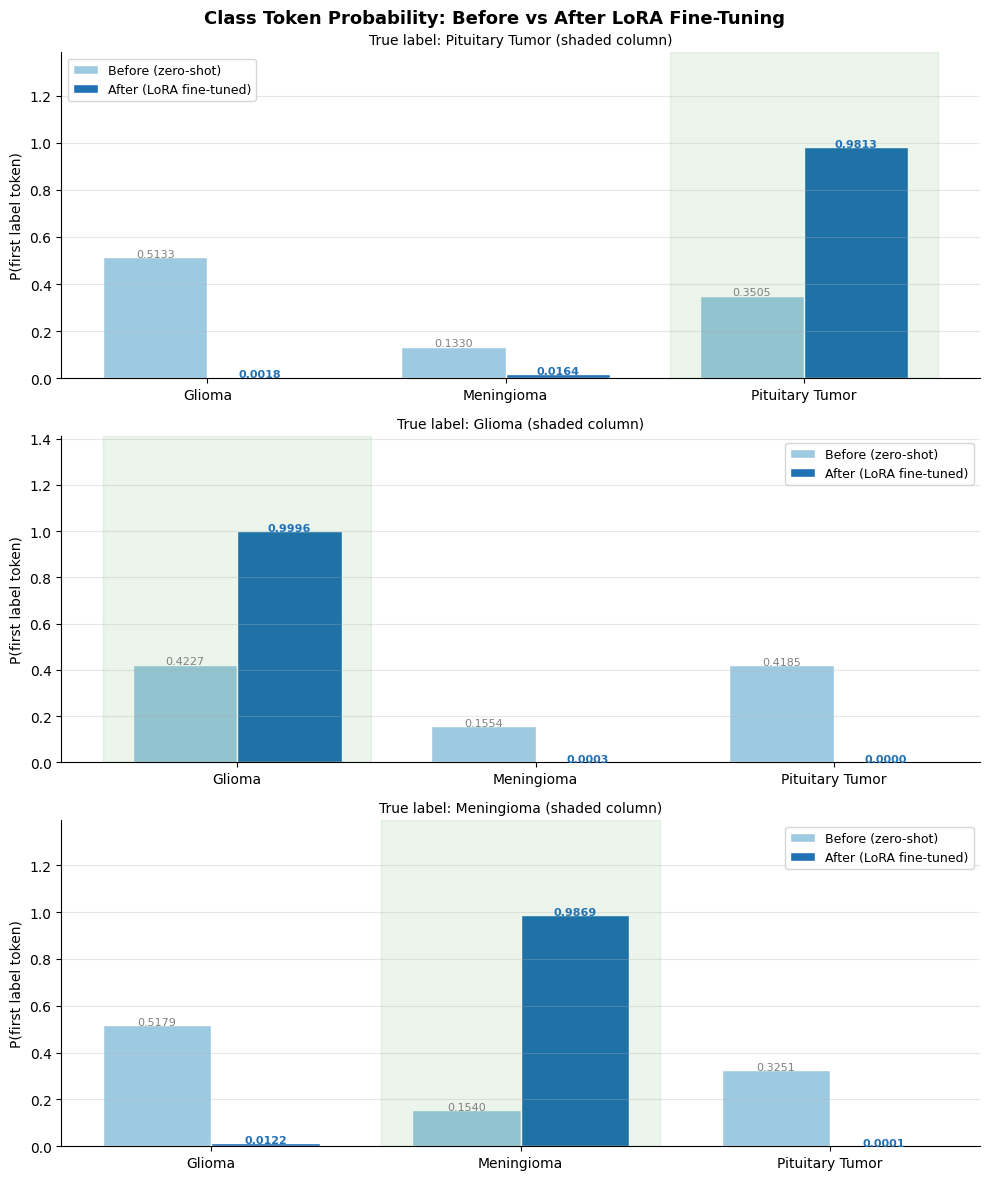

In [34]:
# ── Side-by-side class probability shift ─────────────────────────────────────

fig, axes = plt.subplots(len(probe_samples), 1,
                         figsize=(10, 4 * len(probe_samples)))
fig.suptitle("Class Token Probability: Before vs After LoRA Fine-Tuning",
             fontsize=13, fontweight="bold")

x   = np.arange(len(LABELS))
w   = 0.35

for ax, s in zip(axes, probe_samples):
    true_label = s["label"]
    before  = [ZERO_SHOT_CLASS_PROBS[true_label][l] for l in LABELS]
    after   = [POST_FT_CLASS_PROBS[true_label][l]   for l in LABELS]

    bars_b = ax.bar(x - w/2, before, w, label="Before (zero-shot)",
                    color="#9ecae1", edgecolor="white")
    bars_a = ax.bar(x + w/2, after,  w, label="After (LoRA fine-tuned)",
                    color="#2171b5", edgecolor="white")

    for bar, val in zip(bars_b, before):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", fontsize=8, color="gray")
    for bar, val in zip(bars_a, after):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", fontsize=8, color="#2171b5", fontweight="bold")

    # Highlight the true label column
    true_idx = LABELS.index(true_label)
    ax.axvspan(true_idx - 0.45, true_idx + 0.45, alpha=0.08, color="green")

    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, fontsize=10)
    ax.set_ylabel("P(first label token)")
    ax.set_ylim(0, max(max(before), max(after)) * 1.4 + 0.01)
    ax.set_title(f"True label: {true_label} (shaded column)", fontsize=10)
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/before_after_class_probs.png", dpi=200)
plt.show()

In [35]:
# ── Loss & per-token probability comparison table ─────────────────────────────

rows = []
for s in probe_samples:
    tl = s["label"]
    lp_before, _, loss_before = ZERO_SHOT_TF[tl]
    lp_after,  _, loss_after  = POST_FT_TF[tl]

    # Probability of first answer token
    p_before = lp_before.iloc[0]["target_prob"] if len(lp_before) else None
    p_after  = lp_after.iloc[0]["target_prob"]  if len(lp_after)  else None

    rows.append({
        "True Label": tl,
        "Loss Before":  round(loss_before, 4) if loss_before else None,
        "Loss After":   round(loss_after,  4) if loss_after  else None,
        "Loss Δ":       round((loss_after or 0) - (loss_before or 0), 4),
        "P(token₀) Before": round(p_before, 4) if p_before else None,
        "P(token₀) After":  round(p_after,  4) if p_after  else None,
        "P(token₀) Δ":      round((p_after or 0) - (p_before or 0), 4),
    })

comparison_df = pd.DataFrame(rows)
display(comparison_df)
comparison_df.to_csv("results/before_after_token_prob_comparison.csv", index=False)
print("Saved results/before_after_token_prob_comparison.csv")

,True Label,Loss Before,Loss After,Loss Δ,P(token₀) Before,P(token₀) After,P(token₀) Δ
0,Pituitary Tumor,2.6728,0.0016,-2.6712,1.0,1.0,-0.0
1,Glioma,3.9002,0.0000,-3.9001,1.0,1.0,-0.0
2,Meningioma,3.3841,0.0013,-3.3828,1.0,1.0,-0.0


Saved results/before_after_token_prob_comparison.csv


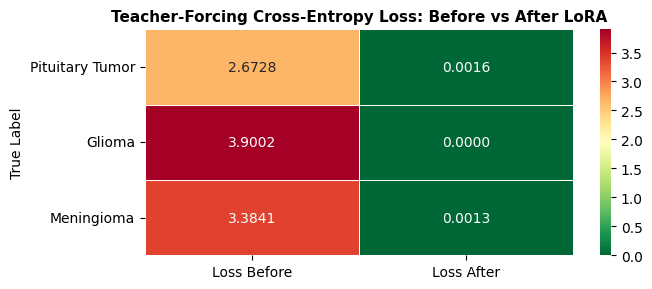

In [36]:
# ── Loss reduction heatmap ────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 3))
hm_data = comparison_df.set_index("True Label")[["Loss Before", "Loss After"]].astype(float)
sns.heatmap(hm_data, annot=True, fmt=".4f", cmap="RdYlGn_r",
            linewidths=0.5, ax=ax, vmin=0)
ax.set_title("Teacher-Forcing Cross-Entropy Loss: Before vs After LoRA",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/before_after_loss_heatmap.png", dpi=200)
plt.show()

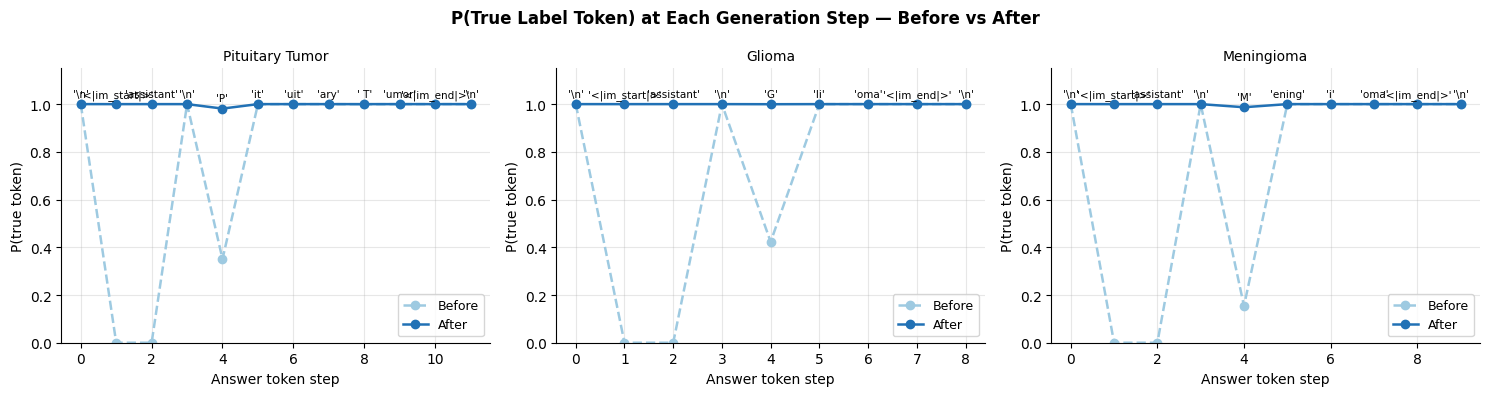

In [37]:
# ── Probability evolution: per-token-step line plot ────────────────────────────

fig, axes = plt.subplots(1, len(probe_samples), figsize=(5 * len(probe_samples), 4))
fig.suptitle("P(True Label Token) at Each Generation Step — Before vs After",
             fontsize=12, fontweight="bold")

for ax, s in zip(axes, probe_samples):
    tl = s["label"]
    lp_b, _, _ = ZERO_SHOT_TF[tl]
    lp_a, _, _ = POST_FT_TF[tl]

    ax.plot(lp_b["step"], lp_b["target_prob"], "o--",
            color="#9ecae1", label="Before", linewidth=1.8)
    ax.plot(lp_a["step"], lp_a["target_prob"], "o-",
            color="#2171b5", label="After",  linewidth=1.8)

    # Annotate token names
    for _, row in lp_a.iterrows():
        ax.text(row["step"], row["target_prob"] + 0.03,
                repr(row["target_decoded"]), ha="center", fontsize=7.5)

    ax.set_ylim(0, 1.15)
    ax.set_xlabel("Answer token step")
    ax.set_ylabel("P(true token)")
    ax.set_title(tl, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/before_after_per_token_prob.png", dpi=200)
plt.show()

## Section 9 — Full Test-Set Evaluation

In [38]:
import re

def clean_prediction(text):
    text = (text or "").strip()
    if not text: return "Unknown"
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r"<[^>]{1,120}>", "", text)
    text = text.replace("**", "").replace("*", "").strip()
    low  = text.lower()
    if "meningioma" in low: return "Meningioma"
    if "glioma"     in low: return "Glioma"
    if "pituitary"  in low: return "Pituitary Tumor"
    for label in sorted(LABELS, key=len, reverse=True):
        if label.lower() in low: return label
    m = re.search(r"\b[012]\b", text)
    if m:
        idx = int(m.group())
        if 0 <= idx < len(LABELS): return LABELS[idx]
    return "Unknown"


def predict_batch(image_paths, batch_size=4, max_new_tokens=8):
    model.eval()
    tok    = processor.tokenizer
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id
    eos_id = tok.eos_token_id
    device = next(model.parameters()).device
    all_outputs = []

    for start in tqdm(range(0, len(image_paths), batch_size)):
        paths   = image_paths[start: start + batch_size]
        images  = [Image.open(p).convert("RGB") for p in paths]
        texts   = [
            processor.apply_chat_template(
                build_vlm_messages(img, answer=None),
                tokenize=False, add_generation_prompt=True)
            for img in images
        ]
        inputs  = processor(text=texts, images=images, return_tensors="pt",
                             padding=True, truncation=True, max_length=MAX_LENGTH)
        inputs  = {k: v.to(device) for k, v in inputs.items()}

        with torch.inference_mode():
            gen_ids = model.generate(
                **inputs, max_new_tokens=max_new_tokens,
                do_sample=False, num_beams=1,
                pad_token_id=pad_id, eos_token_id=eos_id)

        in_len = inputs["input_ids"].shape[1]
        for ids in gen_ids:
            all_outputs.append(
                tok.decode(ids[in_len:], skip_special_tokens=True))

    return all_outputs


print("clean_prediction() and predict_batch() defined.")

clean_prediction() and predict_batch() defined.


In [39]:
test_paths = [item["image"] for item in test_dataset.samples]
y_true     = [item["label"] for item in test_dataset.samples]

raw_outputs = predict_batch(test_paths, batch_size=2, max_new_tokens=8)
y_pred      = [clean_prediction(t) for t in raw_outputs]

acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")
print()
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

# Save predictions
pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "raw": raw_outputs}).to_csv(
    "results/vlm_predictions.csv", index=False)
print("Saved results/vlm_predictions.csv")

100%|██████████| 150/150 [02:29<00:00,  1.00it/s]


Test Accuracy: 0.9467

                 precision    recall  f1-score   support

         Glioma       0.94      0.95      0.95       100
     Meningioma       0.96      0.94      0.95       100
Pituitary Tumor       0.96      0.95      0.95       100

      micro avg       0.95      0.95      0.95       300
      macro avg       0.95      0.95      0.95       300
   weighted avg       0.95      0.95      0.95       300

Saved results/vlm_predictions.csv


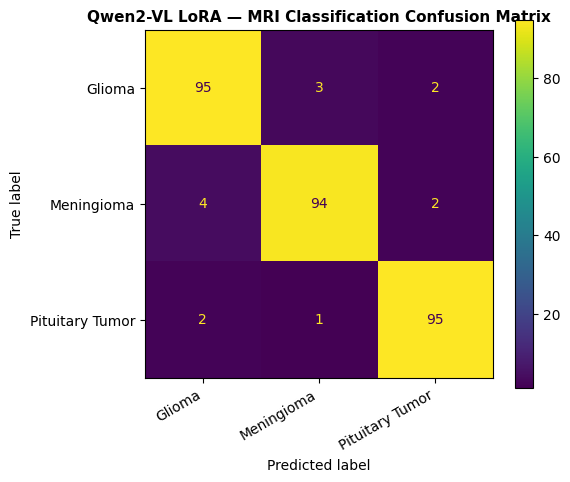

C:\Users\legionPC9\AppData\Local\Temp\ipykernel_29928\407702444.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([


,Class,Precision,Recall,F1-score,Support
0,Glioma,0.940594,0.95,0.945274,100
1,Meningioma,0.959184,0.94,0.949495,100
2,Pituitary Tumor,0.959596,0.95,0.954774,100
3,Overall Accuracy,NaN,NaN,0.946667,300


Saved results/vlm_test_metrics.csv


In [40]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm   = confusion_matrix(y_true, y_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, values_format="d")
ax.set_title("Qwen2-VL LoRA — MRI Classification Confusion Matrix",
             fontsize=11, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=200)
plt.show()

pd.DataFrame(cm, index=LABELS, columns=LABELS).to_csv(
    "results/vlm_confusion_matrix.csv")

prec, rec, f1, sup = precision_recall_fscore_support(
    y_true, y_pred, labels=LABELS, zero_division=0)
metrics_df = pd.DataFrame({
    "Class": LABELS,
    "Precision": prec, "Recall": rec,
    "F1-score": f1,    "Support": sup
})
metrics_df = pd.concat([
    metrics_df,
    pd.DataFrame({"Class": ["Overall Accuracy"], "Precision": [None],
                  "Recall": [None], "F1-score": [acc], "Support": [len(y_true)]})
], ignore_index=True)

display(metrics_df)
metrics_df.to_csv("results/vlm_test_metrics.csv", index=False)
print("Saved results/vlm_test_metrics.csv")

---

## Summary of Key Results

| Probe | Metric | Before Fine-Tuning | After Fine-Tuning |
|-------|--------|-------------------|-----------------|
| Forward-pass | P(correct class token) | ← see `before_after_class_probs.png` | → |
| Teacher-forcing | Cross-entropy loss | ← see `before_after_loss_heatmap.png` | → |
| Per-token | P(each label token) | ← see `before_after_per_token_prob.png` | → |
| Generation | Test accuracy | — | see `vlm_test_metrics.csv` |

### Figures produced

```
figures/
  zero_shot_class_probs.png         ← P(class token) before fine-tuning
  zero_shot_topk_distribution.png   ← top-20 vocab distribution before fine-tuning
  zero_shot_topk_competitors.png    ← competing tokens at answer position
  teacher_forcing_mask.png          ← colour-coded label mask for one sample
  zero_shot_tf_token_probs.png      ← per-step teacher-forcing probs before FT
  training_loss_curve.png           ← train/val CE loss during LoRA training
  before_after_class_probs.png      ← side-by-side class prob shift
  before_after_loss_heatmap.png     ← loss heatmap
  before_after_per_token_prob.png   ← per-token prob before vs after
  confusion_matrix.png              ← final classification results
```

### QA Monitor outputs (new)

| File | Contents |
|------|----------|
| `results/qa_monitor/qa_log.csv` | Raw row per (step, probe sample): prediction, raw output, 3 class probabilities |
| `results/qa_monitor/step_*.png` | Bar chart of class probabilities at each eval checkpoint |
| `results/qa_monitor_summary.csv` | Pivoted summary for quick inspection |
| `figures/qa_monitor_accuracy.png` | Probe accuracy over training steps |
| `figures/qa_monitor_probability_trajectory.png` | Class-token probability curves during training |

### Loss computation clarification (Section 4.2)

The loss at each supervised position $t$ is the **negative log-probability** assigned
by the model to the true answer token at that position:

$$\mathcal{L} = -\frac{1}{|\mathcal{S}|} \sum_{t \in \mathcal{S}} \log p_\theta(y_t \mid x_{<t})$$

where $\mathcal{S}$ excludes all prompt tokens (masked to `-100`).
`Section 4.2` contains a running cell (`compute_ce_loss_breakdown`) that prints
every arithmetic step and verifies it matches `model.out.loss` to within $10^{-4}$.


---
## Section 10 — Inference Test

Interactive check on held-out MRI images: **generation** (predicted class) plus **forward-pass class-token probabilities** (same probe as Sections 3 & 7).

**Prerequisites:** Run the notebook through **Section 9** in order (Setup → data → model → training → full test eval). Fine-tuned weights must be in memory or saved under `OUTPUT_DIR` (`./qwen25vl_7b_mri_lora`).


Using in-memory fine-tuned model.
Inference on 9 test image(s) …


Inference:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\legionPC9\anaconda3\envs\dl\lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Inference:  11%|█         | 1/9 [00:01<00:11,  1.39s/it]

  [OK] true=Pituitary Tumor  pred=Pituitary Tumor  raw='Pituitary Tumor'


Inference:  22%|██▏       | 2/9 [00:02<00:08,  1.23s/it]

  [OK] true=Glioma  pred=Glioma  raw='Glioma'


...

  [OK] true=Pituitary Tumor  pred=Pituitary Tumor  raw='Pituitary Tumor'


Inference: 100%|██████████| 9/9 [00:10<00:00,  1.18s/it]

  [OK] true=Glioma  pred=Glioma  raw='Glioma'

Subset accuracy (9 labeled): 1.0000


,image,true_label,pred_label,raw_output,correct,best_prob_label,p_glioma,p_meningioma,p_pituitary_tumor
0,Dataset\BrainTumorDetection&Classification\Bra...,Pituitary Tumor,Pituitary Tumor,Pituitary Tumor,True,Pituitary Tumor,0.001836,0.016365,0.981317
1,Dataset\BrainTumorDetection&Classification\Bra...,Glioma,Glioma,Glioma,True,Glioma,0.999612,0.000320,0.000015
2,Dataset\BrainTumorDetection&Classification\Bra...,Meningioma,Meningioma,Meningioma,True,Meningioma,0.012231,0.986938,0.000126
3,Dataset\BrainTumorDetection&Classification\Bra...,Meningioma,Meningioma,Meningioma,True,Meningioma,0.000182,0.999563,0.000032
4,Dataset\BrainTumorDetection&Classification\Bra...,Glioma,Glioma,Glioma,True,Glioma,0.996300,0.003538,0.000054
5,Dataset\BrainTumorDetection&Classification\Bra...,Meningioma,Meningioma,Meningioma,True,Meningioma,0.395518,0.603093,0.000396
6,Dataset\BrainTumorDetection&Classification\Bra...,Glioma,Glioma,Glioma,True,Glioma,0.999800,0.000158,0.000005
7,Dataset\BrainTumorDetection&Classification\Bra...,Pituitary Tumor,Pituitary Tumor,Pituitary Tumor,True,Pituitary Tumor,0.000047,0.006192,0.993604
8,Dataset\BrainTumorDetection&Classification\Bra...,Glioma,Glioma,Glioma,True,Glioma,0.999971,0.000010,0.000002


Saved results/vlm_inference_test.csv


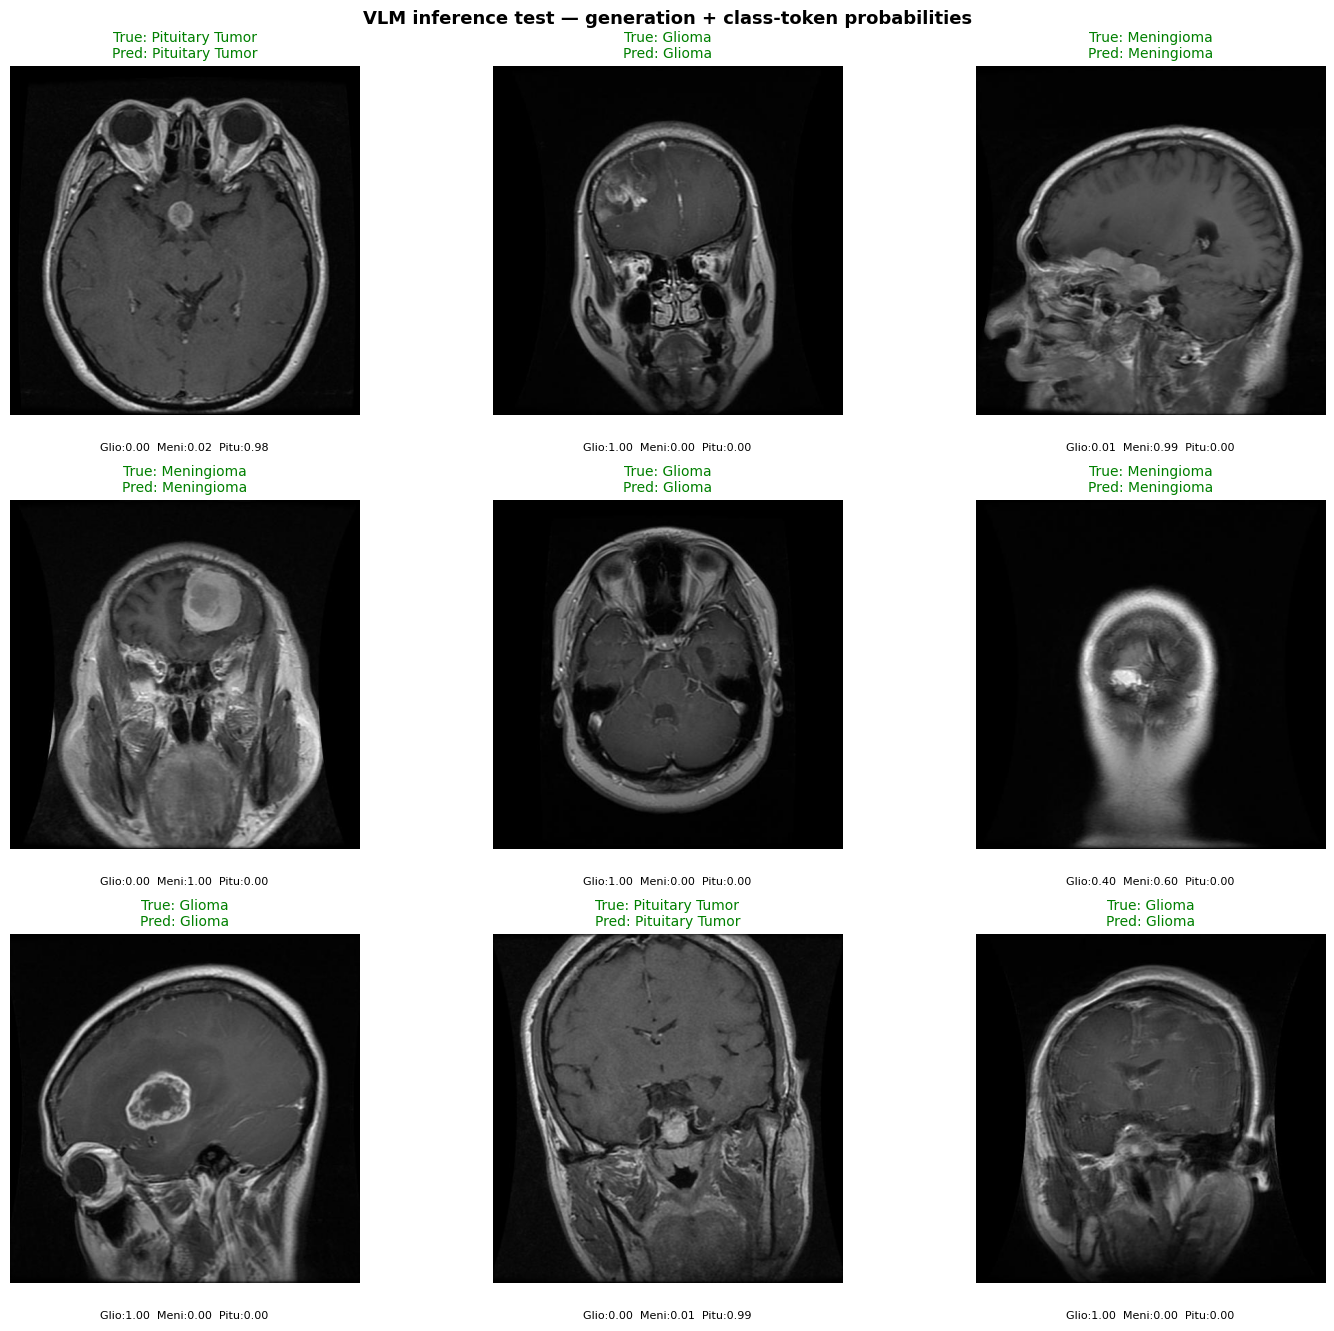

Saved figures/vlm_inference_test.png


In [41]:
# ── Inference test (sample images from test.jsonl) ─────────────────────────
# Run Sections 0–9 first (Setup → … → Section 9). This cell needs predict_batch,
# probe_token_probabilities, and a fine-tuned model in memory or at OUTPUT_DIR.

from peft import PeftModel

INFERENCE_N_PER_CLASS = 1   # one example per tumour class
INFERENCE_N_RANDOM = 6      # extra random test images (set 0 to skip)
INFERENCE_MAX_NEW_TOKENS = 8
_INFERENCE_SEED = globals().get("SEED", 42)

_REQUIRED = {
    "predict_batch": "Section 9",
    "clean_prediction": "Section 9",
    "probe_token_probabilities": "Section 3",
    "build_vlm_messages": "Section 2b",
    "ensure_processor": "Section 2",
    "LABELS": "Section 0",
}
for _name, _sec in _REQUIRED.items():
    if _name not in globals():
        raise RuntimeError(f"Run {_sec} first (missing `{_name}`).")

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = "./qwen25vl_7b_mri_lora"


def _first_sample_per_class(jsonl_path):
    seen, samples = set(), []
    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            if r["label"] not in seen:
                samples.append(r)
                seen.add(r["label"])
            if len(seen) == len(LABELS):
                break
    return samples


def load_model_for_inference():
    """Use in-memory fine-tuned weights, or load LoRA adapter from OUTPUT_DIR."""
    global model
    ensure_processor()
    adapter_cfg = os.path.join(OUTPUT_DIR, "adapter_config.json")
    if globals().get("model") is not None:
        model.eval()
        print("Using in-memory fine-tuned model.")
        return model
    if not os.path.isfile(adapter_cfg):
        raise FileNotFoundError(
            f"No adapter at {OUTPUT_DIR}. Run Section 6 (fine-tuning) first."
        )
    ensure_processor()
    load_path = MODEL_LOAD_PATH
    if torch.cuda.is_available():
        bnb = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        base = AutoModelForImageTextToText.from_pretrained(
            load_path,
            quantization_config=bnb,
            device_map={"": 0},
            trust_remote_code=True,
            local_files_only=True,
        )
    else:
        base = AutoModelForImageTextToText.from_pretrained(
            load_path,
            device_map=None,
            trust_remote_code=True,
            local_files_only=True,
        )
    model = PeftModel.from_pretrained(base, OUTPUT_DIR)
    model.eval()
    print(f"Loaded fine-tuned adapter from {OUTPUT_DIR}")
    return model


def _prob_col(label):
    return "p_" + label.replace(" ", "_").lower()


def pick_inference_samples(n_per_class=1, n_random=6, seed=None):
    """Build a small test list: optional one-per-class + random extras."""
    if seed is None:
        seed = _INFERENCE_SEED
    rows = []
    seen = set()
    pick_one = globals().get("first_sample_per_class", _first_sample_per_class)
    if n_per_class > 0:
        for s in pick_one("test.jsonl"):
            rows.append(s)
            seen.add(s["image"])
    if n_random > 0:
        with open("test.jsonl", encoding="utf-8") as f:
            pool = [json.loads(line) for line in f]
        rng = random.Random(seed)
        extra = [s for s in pool if s["image"] not in seen]
        rng.shuffle(extra)
        rows.extend(extra[:n_random])
    return rows


def infer_one_sample(image_path, true_label=None):
    """Run generation + class-token probe on a single image."""
    raw = predict_batch(
        [image_path], batch_size=1, max_new_tokens=INFERENCE_MAX_NEW_TOKENS
    )[0]
    pred = clean_prediction(raw)
    _, class_probs = probe_token_probabilities(image_path, top_k=10)
    best_prob_label = max(class_probs, key=class_probs.get)
    return {
        "image": image_path,
        "true_label": true_label,
        "pred_label": pred,
        "raw_output": raw,
        "correct": (true_label == pred) if true_label else None,
        "best_prob_label": best_prob_label,
        **{_prob_col(lbl): class_probs[lbl] for lbl in LABELS},
    }


def plot_inference_grid(results, cols=3, save_path="figures/vlm_inference_test.png"):
    n = len(results)
    cols = min(cols, max(1, n))
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
    axes = np.atleast_1d(axes)
    if axes.ndim == 1 and rows == 1:
        axes = axes.reshape(1, -1)
    elif axes.ndim == 1 and cols == 1:
        axes = axes.reshape(-1, 1)
    fig.suptitle(
        "VLM inference test — generation + class-token probabilities",
        fontsize=13,
        fontweight="bold",
    )

    for ax, r in zip(axes.ravel(), results):
        img = Image.open(r["image"]).convert("RGB")
        ax.imshow(img, cmap="gray")
        ok = r.get("correct")
        title_color = "green" if ok else ("red" if ok is False else "black")
        ax.set_title(
            f"True: {r.get('true_label', '?')}\nPred: {r['pred_label']}",
            fontsize=10,
            color=title_color,
        )
        ax.axis("off")
        prob_txt = "  ".join(
            f"{lbl[:4]}:{r.get(_prob_col(lbl), 0):.2f}" for lbl in LABELS
        )
        ax.text(
            0.5, -0.08, prob_txt, transform=ax.transAxes,
            ha="center", va="top", fontsize=8,
        )

    for ax in axes.ravel()[n:]:
        ax.axis("off")

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path}")


# ── Run inference ─────────────────────────────────────────────────────────────
load_model_for_inference()

inference_samples = pick_inference_samples(
    n_per_class=INFERENCE_N_PER_CLASS,
    n_random=INFERENCE_N_RANDOM,
)

print(f"Inference on {len(inference_samples)} test image(s) …")
inference_rows = []
for s in tqdm(inference_samples, desc="Inference"):
    row = infer_one_sample(s["image"], true_label=s["label"])
    inference_rows.append(row)
    mark = "OK" if row["correct"] else "WRONG"
    print(
        f"  [{mark}] true={row['true_label']}  pred={row['pred_label']}  "
        f"raw={row['raw_output']!r}"
    )

inference_df = pd.DataFrame(inference_rows)
n_labeled = int(inference_df["correct"].notna().sum())
if n_labeled:
    acc = float(inference_df["correct"].mean())
    print(f"\nSubset accuracy ({n_labeled} labeled): {acc:.4f}")

prob_cols = [_prob_col(l) for l in LABELS]
display(inference_df[
    ["image", "true_label", "pred_label", "raw_output", "correct", "best_prob_label"]
    + prob_cols
])

os.makedirs("results", exist_ok=True)
inference_df.to_csv("results/vlm_inference_test.csv", index=False)
print("Saved results/vlm_inference_test.csv")

plot_inference_grid(inference_rows)
